<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_TP4/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_4_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP4 - Aprendizaje no supervisado

#Ejercicio 1 - Triaje oncológico asistido por algoritmos


---
**Datasets:** `datos_pacientes.csv` y `datos_pacientes_diagnosticados.csv`

**Grupo:** Numero 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/2026

>Un hospital regional de mediana complejidad atiende una cantidad creciente de pacientes derivados con
sospecha de tumor mamario. El cuello de botella no es la tecnología de diagnóstico (el hospital dispone
de equipamiento para biopsia digital) sino la disponibilidad del personal médico especializado: por
restricciones de recursos humanos, el equipo de oncología puede analizar y emitir diagnóstico definitivo
(benigno o maligno) para no más de 2 pacientes por día.
Actualmente hay 560 pacientes con estudios preliminares ya realizados en el sistema, esperando
diagnóstico. A ese ritmo, el último paciente de la lista esperaría 280 días. Para tumores malignos, esa
demora puede ser la diferencia entre un tratamiento efectivo y uno tardío.
El jefe del servicio de oncología propone implementar un sistema de triaje asistido por algoritmos: usar los
valores de los estudios preliminares disponibles para todos los pacientes (datos_pacientes.csv) para
identificar automáticamente cuáles tienen mayor probabilidad de tumor maligno y priorizarlos en la
agenda. Para calibrar y validar el sistema, el servicio dispone de un conjunto reducido de pacientes ya
diagnosticados por el equipo médico (datos_pacientes_diagnosticados.csv), con su resultado confirmado.
El dataset de estudios contiene 30 características computadas a partir de imágenes digitalizadas de
biopsias. El conjunto diagnosticado incluye, además, la columna diagnosis (M = maligno, B = benigno).
El jefe del servicio no rechazará el sistema si tiene un error ocasional. Lo rechazará si no puede entender
qué hace, si produce resultados inconsistentes o si no puede cuantificar el riesgo de que un paciente
maligno quede al final de la lista.





---


## 0. Configuración del entorno

In [1]:
# Dataset desde el repositorio en Drive

!wget -c --no-check-certificate "https://drive.google.com/uc?export=download&id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&confirm=t" -O datos_pacientes.zip

--2026-04-23 18:09:42--  https://drive.google.com/uc?export=download&id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&confirm=t
Resolving drive.google.com (drive.google.com)... 173.194.194.138, 173.194.194.101, 173.194.194.139, ...
Connecting to drive.google.com (drive.google.com)|173.194.194.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&export=download [following]
--2026-04-23 18:09:42--  https://drive.usercontent.google.com/download?id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.201.132, 2607:f8b0:4001:c01::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.201.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50200 (49K) [application/octet-stream]
Saving to: ‘datos_pacientes.zip’

datos_pacientes.zip 100%[===================>]  

In [2]:
!unzip datos_pacientes.zip

Archive:  datos_pacientes.zip
  inflating: datos_pacientes_diagnosticados.csv  
  inflating: datos_pacientes.csv     


In [3]:
# @title *Esta celda importa utilidades comunes al colab*
# @title Importaciones
import sys, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    silhouette_samples
)
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.pipeline import Pipeline

try:
    import umap
except ImportError:
    !pip install umap-learn -q
    import umap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
print("Entorno listo.")


Entorno listo.


### 0.1 EDA

In [4]:
df_pacientes = pd.read_csv('datos_pacientes.csv')
df_pacientes_diagnosticados = pd.read_csv('datos_pacientes_diagnosticados.csv')

Se muestran los primeros 5 pacientes del dataset_pacientes y revisamos el dataset_pacientes_diagnosticados por completo

In [5]:
print("=== dataset_pacientes ===")
print(f"Dimensión: {df_pacientes.shape}  ({df_pacientes.shape[0]} pacientes, {df_pacientes.shape[1]} columnas)")
print(f"Columnas: {list(df_pacientes.columns)}")
df_pacientes.head()

=== dataset_pacientes ===
Dimensión: (560, 31)  (560 pacientes, 31 columnas)
Columnas: ['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,915940,14.580,13.66,94.29,658.8,0.09832,0.08918,0.08222,0.043490,0.1739,...,16.76,17.24,108.50,862.0,0.1223,0.1928,0.24920,0.09186,0.2626,0.07048
1,893988,11.540,10.72,73.73,409.1,0.08597,0.05969,0.01367,0.008907,0.1833,...,12.34,12.87,81.23,467.8,0.1092,0.1626,0.08324,0.04715,0.3390,0.07434
2,8910251,10.600,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.026420,0.1922,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.19160,0.07926,0.2940,0.07587
3,8510824,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,10.23,15.66,65.13,314.9,0.1324,0.1148,0.08867,0.06227,0.2450,0.07773
4,90944601,13.780,15.79,88.37,585.9,0.08817,0.06718,0.01055,0.009937,0.1405,...,15.27,17.50,97.90,706.6,0.1072,0.1071,0.03517,0.03312,0.1859,0.06810


In [6]:
print("=== dataset_pacientes_diagnosticados ===")
print(f"Dimensión: {df_pacientes_diagnosticados.shape}  ({df_pacientes_diagnosticados.shape[0]} pacientes, {df_pacientes_diagnosticados.shape[1]} columnas)")
print(f"Distribución de diagnóstico:\n{df_pacientes_diagnosticados['diagnosis'].value_counts()}")
df_pacientes_diagnosticados.head()

=== dataset_pacientes_diagnosticados ===
Dimensión: (9, 32)  (9 pacientes, 32 columnas)
Distribución de diagnóstico:
diagnosis
B    6
M    3
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,898677,B,10.26,14.71,66.20,321.6,0.09882,0.09159,0.035810,0.020370,...,10.88,19.48,70.89,357.1,0.1360,0.1636,0.07162,0.04074,0.2434,0.08488
1,913505,M,19.44,18.82,128.10,1167.0,0.10890,0.14480,0.225600,0.119400,...,23.96,30.39,153.90,1740.0,0.1514,0.3725,0.59360,0.20600,0.3266,0.09009
2,912519,B,13.47,14.06,87.32,546.3,0.10710,0.11550,0.057860,0.052660,...,14.83,18.32,94.94,660.2,0.1393,0.2499,0.18480,0.13350,0.3227,0.09326
3,84667401,M,13.73,22.61,93.60,578.3,0.11310,0.22930,0.212800,0.080250,...,15.03,32.01,108.80,697.7,0.1651,0.7725,0.69430,0.22080,0.3596,0.14310
4,874158,B,10.08,15.11,63.76,317.5,0.09267,0.04695,0.001597,0.002404,...,11.87,21.18,75.39,437.0,0.1521,0.1019,0.00692,0.01042,0.2933,0.07697


Vamos a revisar si hay valores nulos en ambas datasets

In [7]:
# Verificación de nulos
print("Nulos en datos_pacientes:")
print(df_pacientes.isnull().sum().sum(), "valores nulos totales")
print("\nNulos en datos_pacientes_diagnosticados:")
print(df_pacientes_diagnosticados.isnull().sum().sum(), "valores nulos totales")

Nulos en datos_pacientes:
0 valores nulos totales

Nulos en datos_pacientes_diagnosticados:
0 valores nulos totales


In [8]:
# Estadísticas descriptivas de los 560 pacientes
df_pacientes.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std", "min", "max"])

,count,mean,std,min,25%,50%,75%,max
id,560.000000,30536072.607143,125933045.657819,8670.000000,869222.500000,906157.000000,8825022.250000,911320502.000000
radius_mean,560.000000,14.139805,3.524507,6.981000,11.707500,13.355000,15.797500,28.110000
texture_mean,560.000000,19.343804,4.288002,9.710000,16.292500,18.890000,21.812500,39.280000
perimeter_mean,560.000000,92.048107,24.307755,43.790000,75.200000,86.210000,104.150000,188.500000
area_mean,560.000000,656.062500,352.594258,143.500000,420.300000,551.400000,784.150000,2501.000000
smoothness_mean,560.000000,0.096239,0.014122,0.052630,0.085992,0.095720,0.105150,0.163400
compactness_mean,560.000000,0.104211,0.052825,0.019380,0.064815,0.092525,0.130425,0.345400
concavity_mean,560.000000,0.088747,0.079782,0.000000,0.029540,0.061400,0.131000,0.426800
concave points_mean,560.000000,0.048890,0.038822,0.000000,0.020310,0.033455,0.073730,0.201200
symmetry_mean,560.000000,0.181178,0.027575,0.106000,0.161875,0.179250,0.195700,0.304000


### 0.2 Distribución de las features

Visualizamos la distribución de las 30 features para detectar asimetrías, outliers y ver las escalas.

Total de features: 30


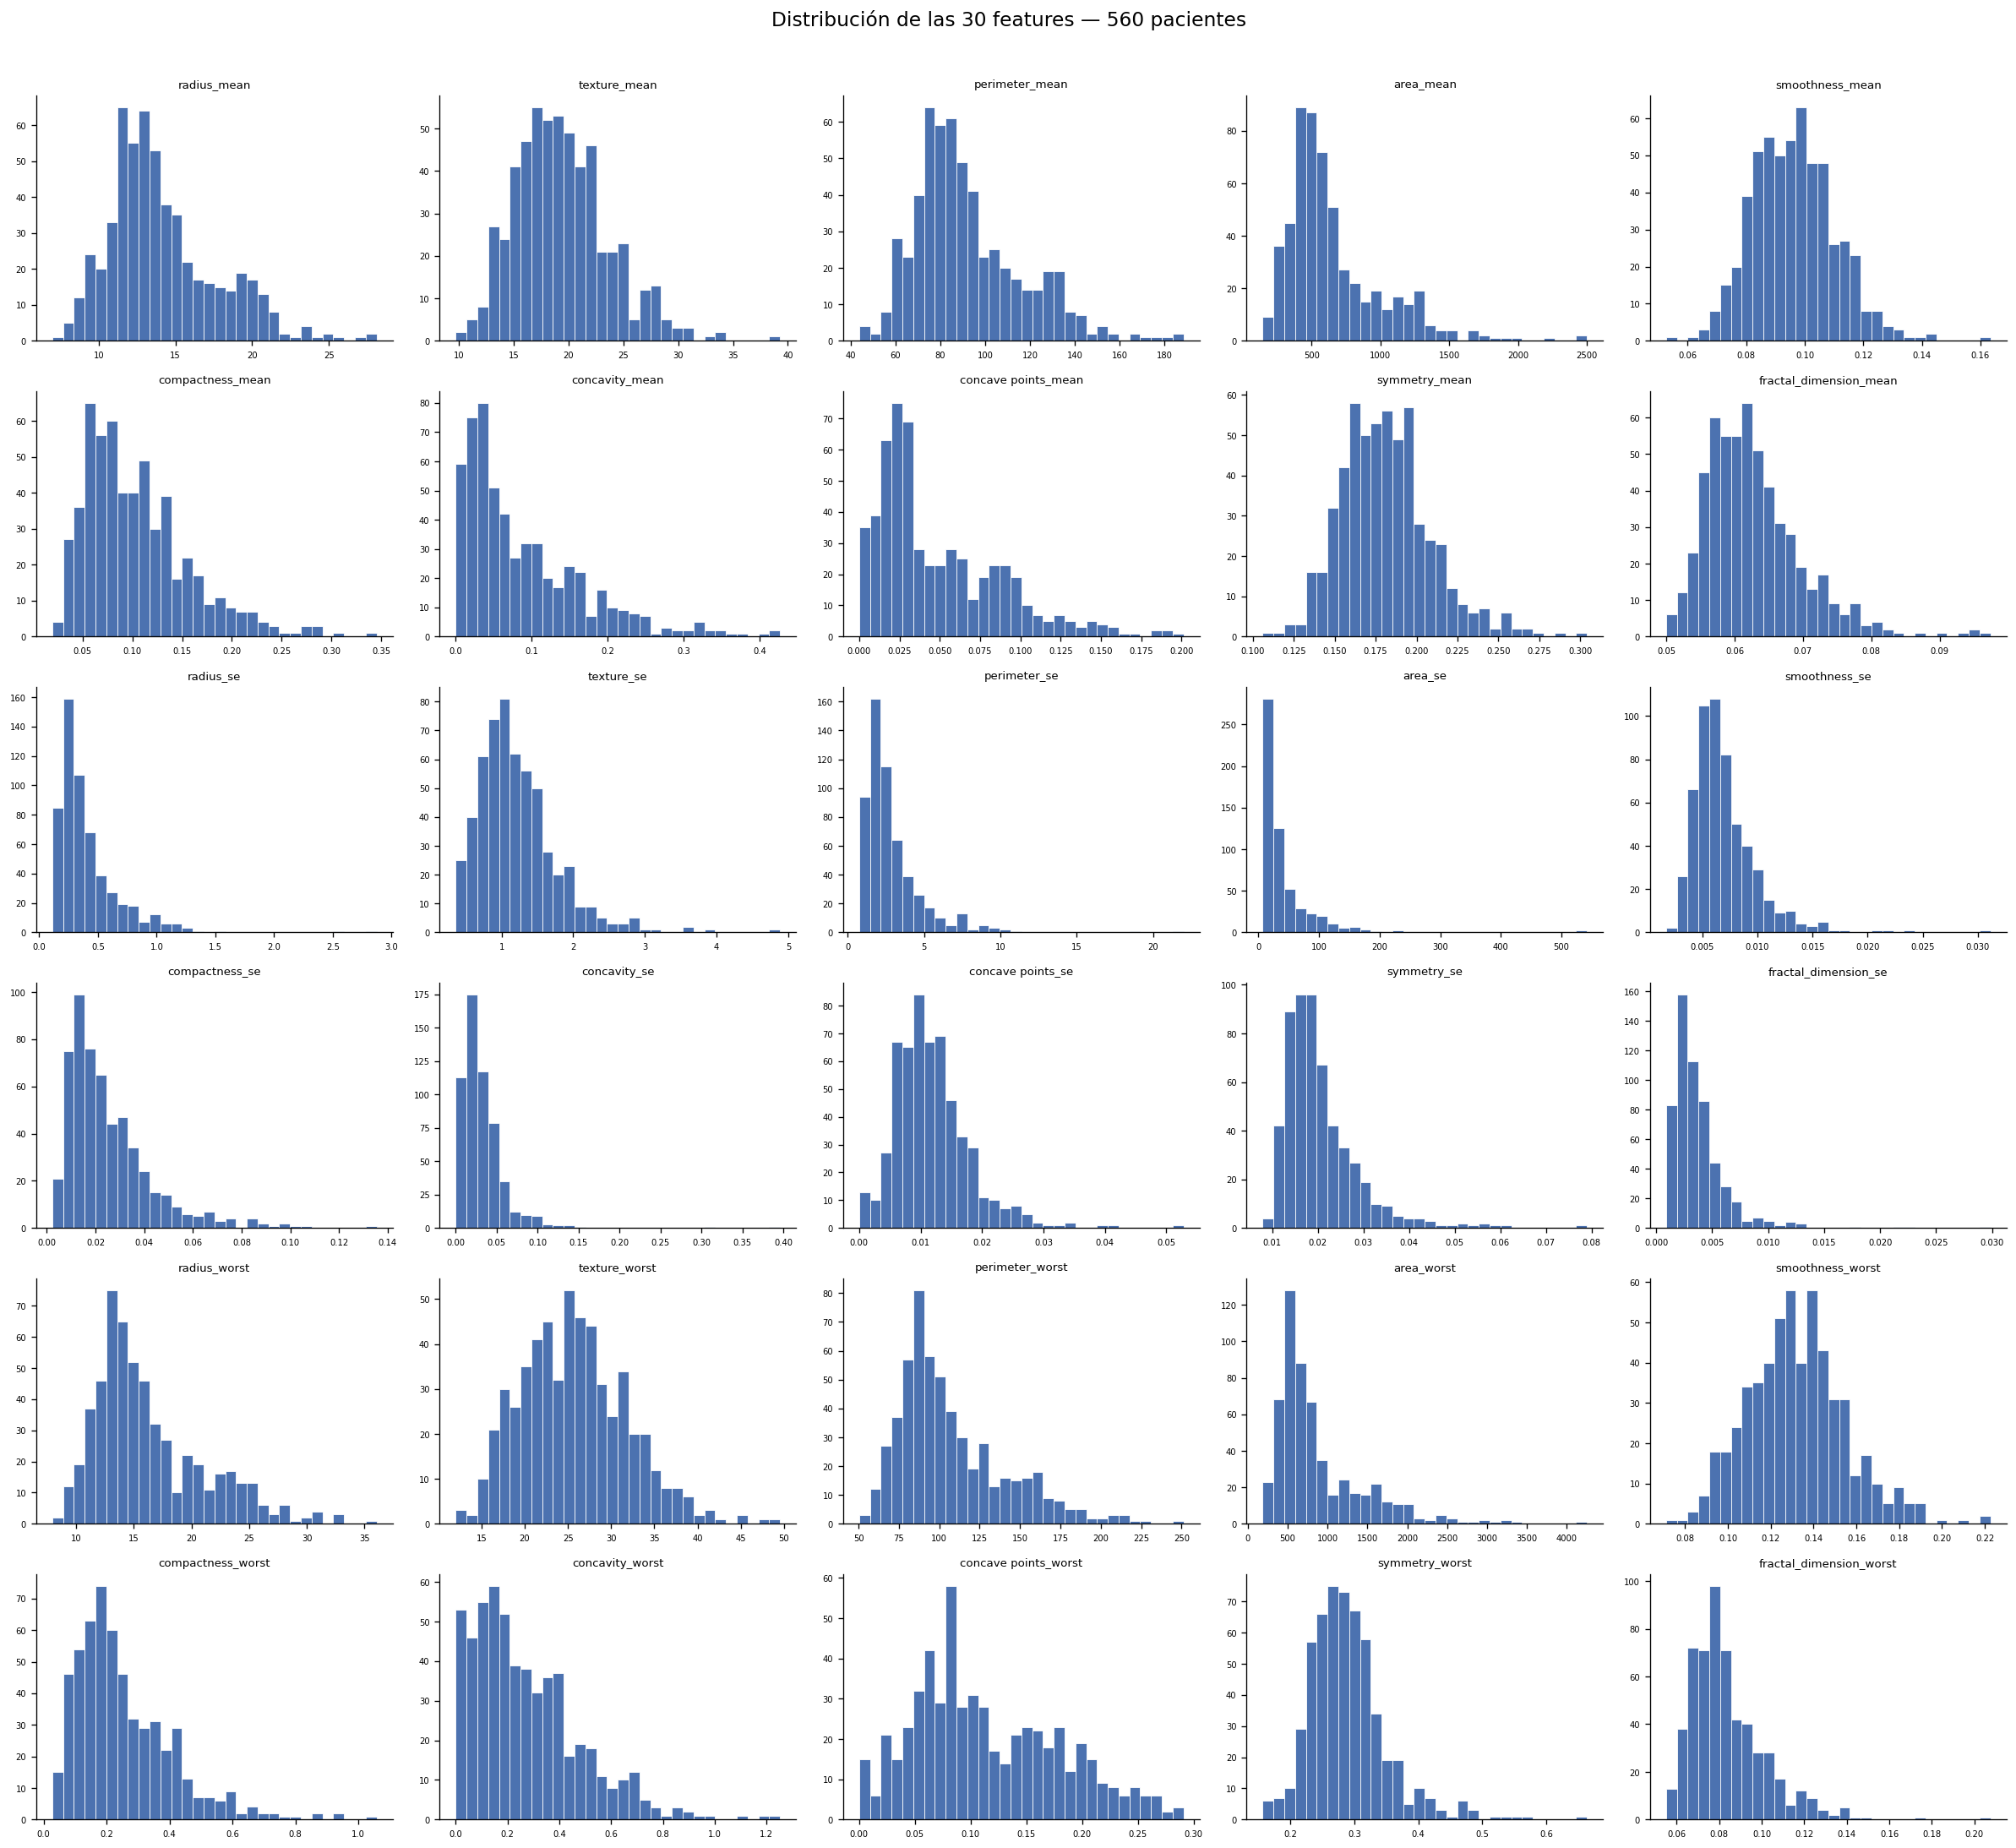

In [9]:
# Identificar columnas de features (excluir id)
feature_cols = [c for c in df_pacientes.columns if c != "id"]
print(f"Total de features: {len(feature_cols)}")

fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df_pacientes[col], bins=30, color="#4C72B0", edgecolor="white", linewidth=0.5)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=6)
plt.suptitle("Distribución de las 30 features — 560 pacientes", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Se aprecian que las features tienen distintas escalas (justificación para aplicar `StandardScaler`).

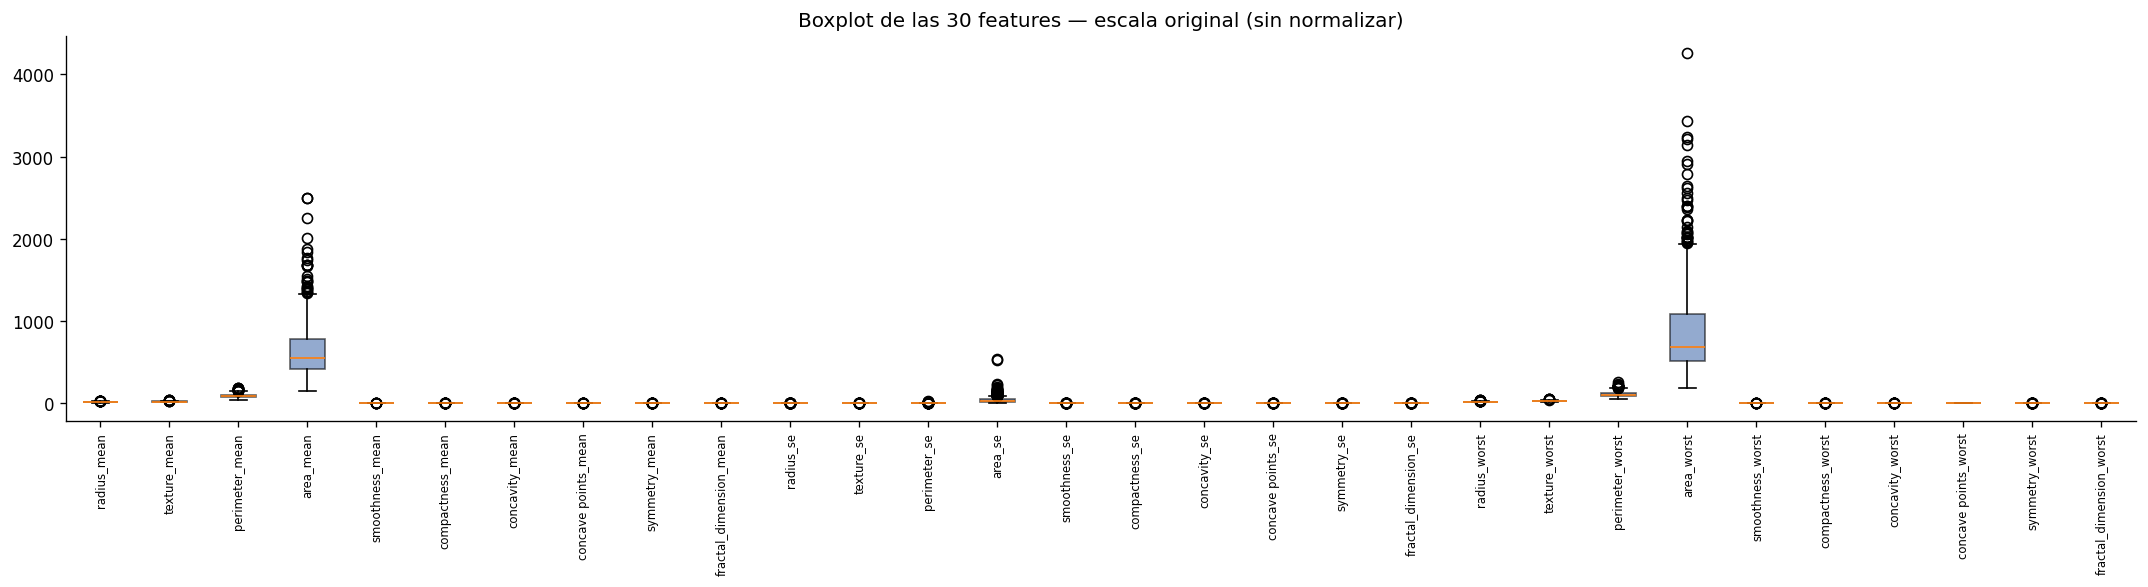

In [10]:
# Boxplot para visualizar rango y outliers por feature
X_raw = df_pacientes[feature_cols].values
fig, ax = plt.subplots(figsize=(18, 5))
ax.boxplot(X_raw, labels=feature_cols, vert=True, patch_artist=True,
           boxprops=dict(facecolor="#4C72B0", alpha=0.6))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=7)
ax.set_title("Boxplot de las 30 features — escala original (sin normalizar)")
plt.tight_layout()
plt.show()

Observación: features como area_mean tienen rango de ~1000 mientras que smoothness_mean tiene rango ~0.1. Sin escalar, K-Means basado en distancias euclidianas estaría dominado por las features de mayor magnitud.

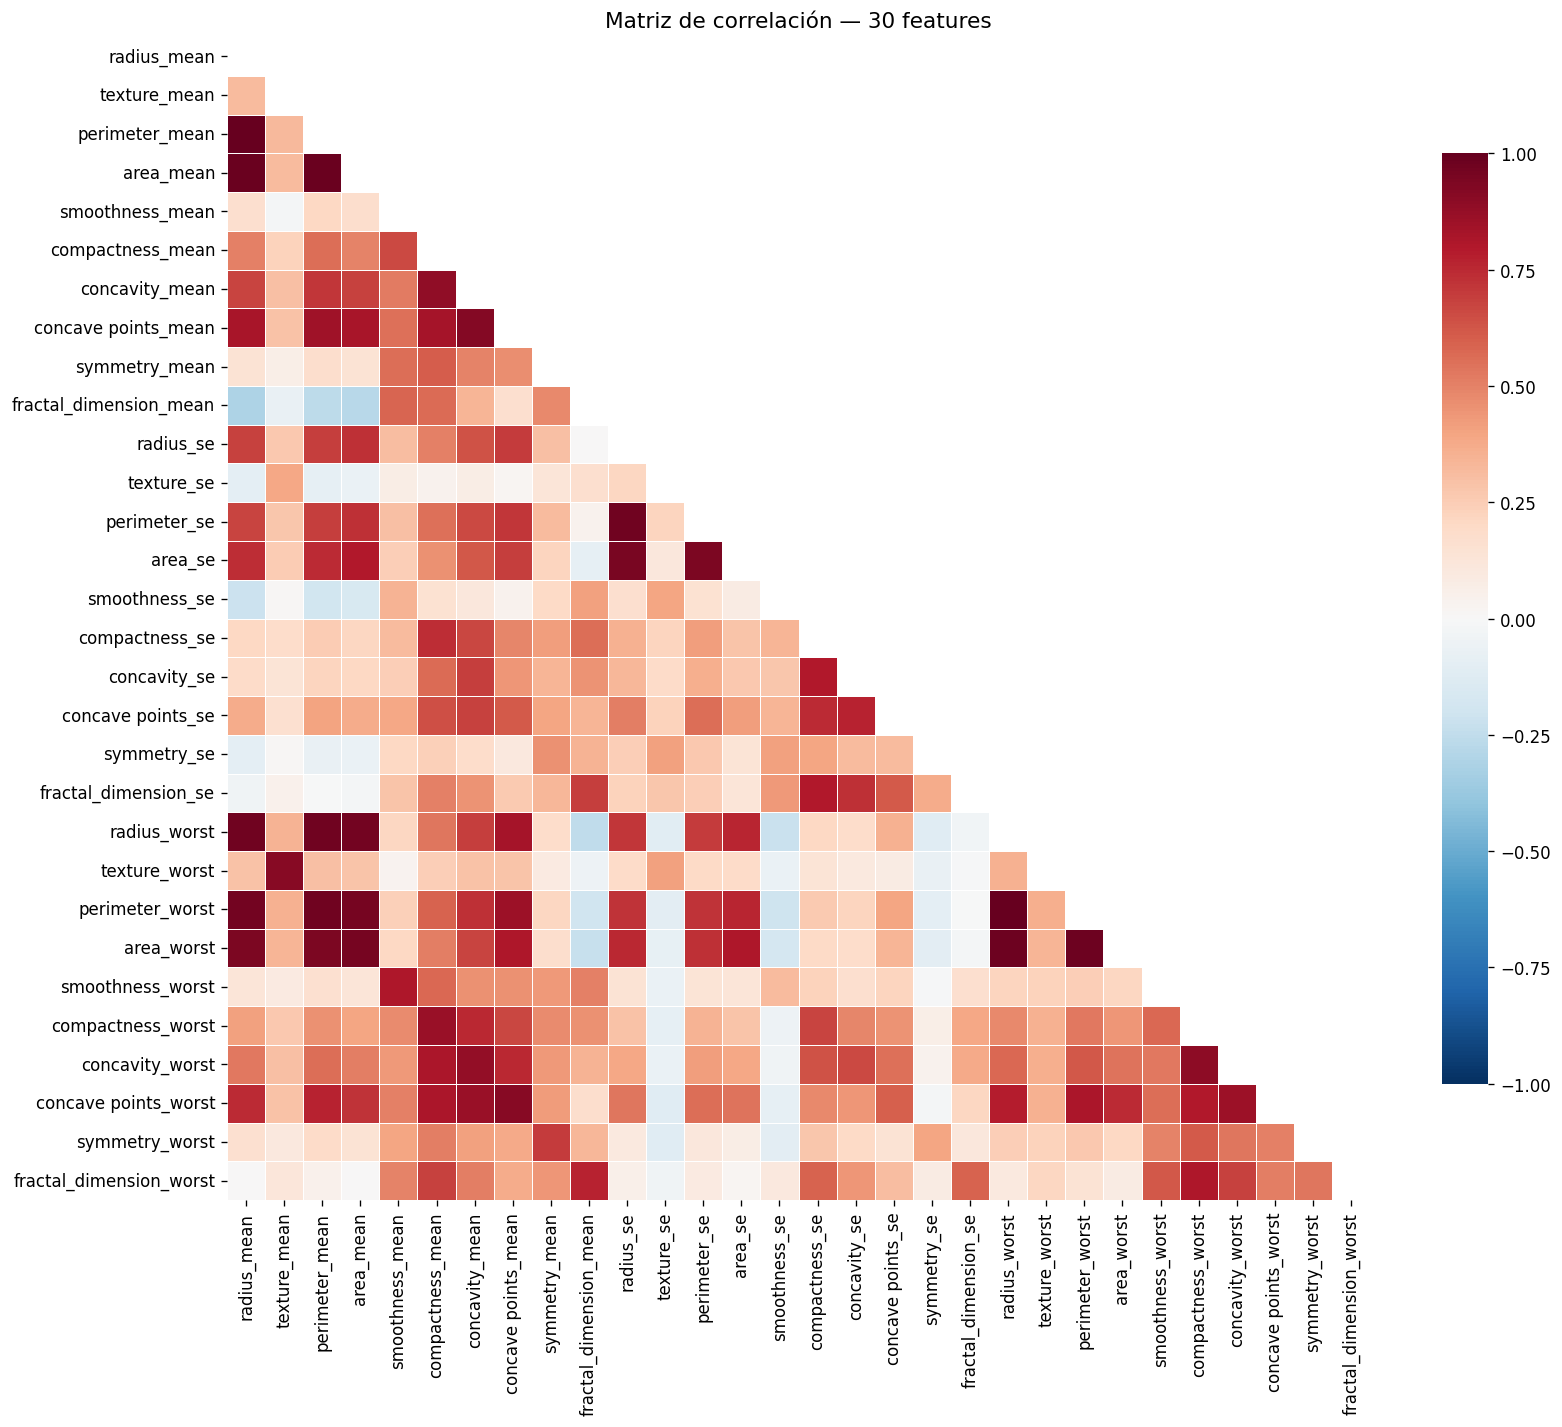

In [11]:
# Mapa de correlación — permite ver si hay redundancia entre features
corr = df_pacientes[feature_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de correlación — 30 features", fontsize=13)
plt.tight_layout()
plt.show()

Observación: alta correlación entre features de la misma familia (ej: radius_mean, area_mean, perimeter_mean). Esto sugiere que PCA podrá capturar gran parte de la varianza en pocos componentes.



---


##1. Construcción del Pipeline de Preprocesamiento

El único paso de preprocesamiento necesario es **estandarización** con `StandardScaler`:

- Lleva todas las features a media 0 y desviación estándar 1
- Fundamental para K-Means, que usa distancias euclidianas
- Sin escalar, `area_mean` (1000) dominaría completamente sobre `smoothness_mean` (~0.1)
- La columna `id` se descarta para el modelado (se preserva para identificación final)

In [12]:
# Separar IDs y features
ids_pac = df_pacientes["id"].values
X_raw = df_pacientes[feature_cols].values

# Pipeline de preprocesamiento
preprocesador = Pipeline([
    ("scaler", StandardScaler())
])

X_scaled = preprocesador.fit_transform(X_raw)

print(f"Shape antes de escalar: {X_raw.shape}")
print(f"Shape después de escalar: {X_scaled.shape}")
print(f"\nMedia post-scaling (debe ser ~0): {X_scaled.mean(axis=0).mean():.6f}")
print(f"Std post-scaling (debe ser ~1): {X_scaled.std(axis=0).mean():.6f}")

# También preparar el dataset diagnosticado
X_diag_raw = df_pacientes_diagnosticados[feature_cols].values
X_diag_scaled = preprocesador.transform(X_diag_raw)  # transform, NO fit_transform
y_diag = df_pacientes_diagnosticados["diagnosis"].values  # M / B
print(f"\nDataset diagnosticado escalado: {X_diag_scaled.shape}")
print(f"Diagnósticos: {pd.Series(y_diag).value_counts().to_dict()}")

Shape antes de escalar: (560, 30)
Shape después de escalar: (560, 30)

Media post-scaling (debe ser ~0): -0.000000
Std post-scaling (debe ser ~1): 1.000000

Dataset diagnosticado escalado: (9, 30)
Diagnósticos: {'B': 6, 'M': 3}


## 2. Reduccion de Dimensionalidad y Visualización

Las 30 features haran que sea dificil visualizar los datos, entonces se pueden optar por el uso de tecnicas para reducir la dimensionalidad, algunas tecnicas son:

*   PCA
*   t-SNE
*   UMAP

Los pacientes diagnosticados como M se pintarán de rojo y los diagnosticados como B de verde.



---


##2. Reducción de Dimensionalidad y Visualización

### 2.1 PCA — Principal Component Analysis

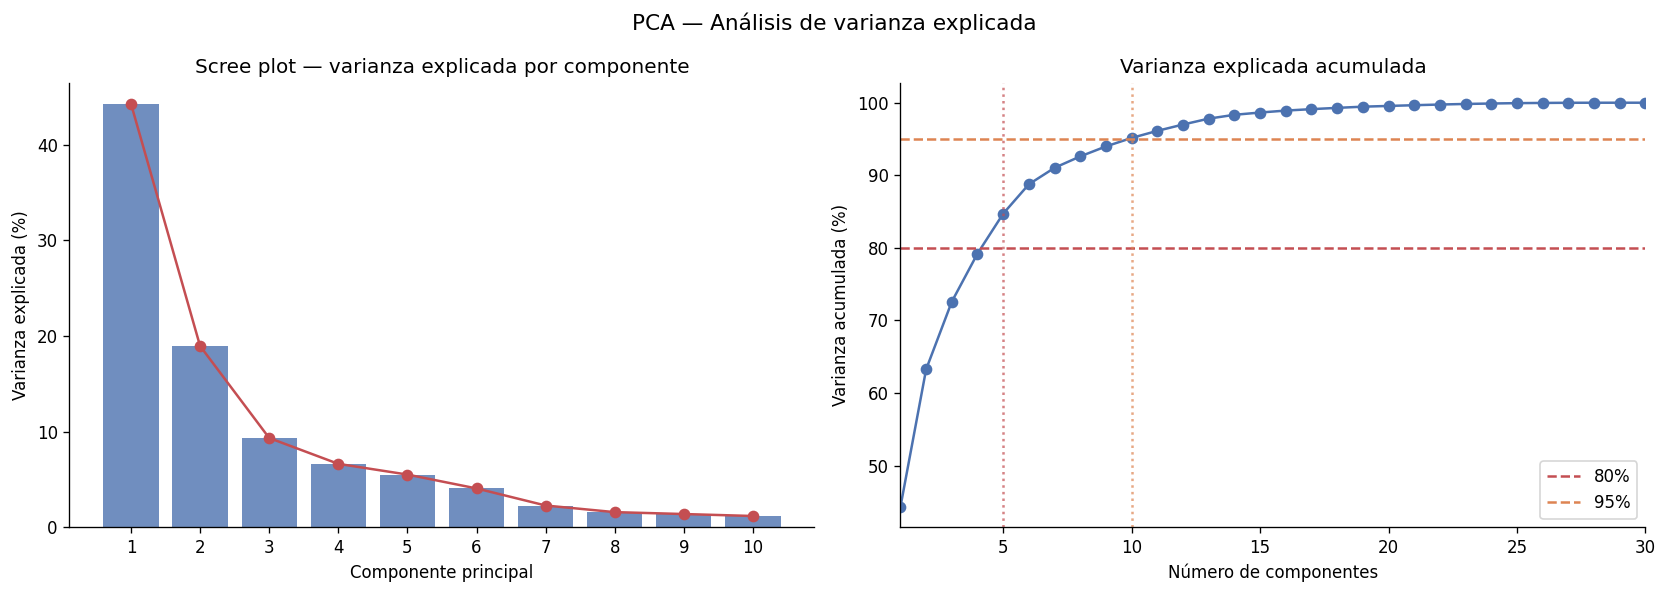

PC1: 44.3% de varianza
PC2: 19.0% de varianza
PC1+PC2 combinados: 63.3% de varianza

Componentes necesarios para explicar el 80% de la varianza: 5
Componentes necesarios para explicar el 95% de la varianza: 10

Interpretación: al proyectar a 2D con PCA perdemos ~36.7% de la información.
Sin embargo, si la estructura de separación está principalmente en los primeros PC,
la visualización 2D puede ser muy representativa.


In [13]:
# PCA completo para ver varianza explicada
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.bar(range(1, 11), pca_full.explained_variance_ratio_[:10] * 100, color="#4C72B0", alpha=0.8)
ax1.plot(range(1, 11), pca_full.explained_variance_ratio_[:10] * 100, "o-", color="#C44E52")
ax1.set_xlabel("Componente principal")
ax1.set_ylabel("Varianza explicada (%)")
ax1.set_title("Scree plot — varianza explicada por componente")
ax1.set_xticks(range(1, 11))

# Varianza acumulada
ax2.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada * 100, "o-", color="#4C72B0")
ax2.axhline(80, ls="--", color="#C44E52", label="80%")
ax2.axhline(95, ls="--", color="#DD8452", label="95%")
n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1
ax2.axvline(n_80, ls=":", color="#C44E52", alpha=0.7)
ax2.axvline(n_95, ls=":", color="#DD8452", alpha=0.7)
ax2.set_xlabel("Número de componentes")
ax2.set_ylabel("Varianza acumulada (%)")
ax2.set_title("Varianza explicada acumulada")
ax2.legend()
ax2.set_xlim(1, 30)

plt.suptitle("PCA — Análisis de varianza explicada", fontsize=13)
plt.tight_layout()
plt.show()

pc1_var = pca_full.explained_variance_ratio_[0] * 100
pc2_var = pca_full.explained_variance_ratio_[1] * 100
print(f"PC1: {pc1_var:.1f}% de varianza")
print(f"PC2: {pc2_var:.1f}% de varianza")
print(f"PC1+PC2 combinados: {pc1_var + pc2_var:.1f}% de varianza")
print(f"\nComponentes necesarios para explicar el 80% de la varianza: {n_80}")
print(f"Componentes necesarios para explicar el 95% de la varianza: {n_95}")
print(f"\nInterpretación: al proyectar a 2D con PCA perdemos ~{100-(pc1_var+pc2_var):.1f}% de la información.")
print("Sin embargo, si la estructura de separación está principalmente en los primeros PC,")
print("la visualización 2D puede ser muy representativa.")

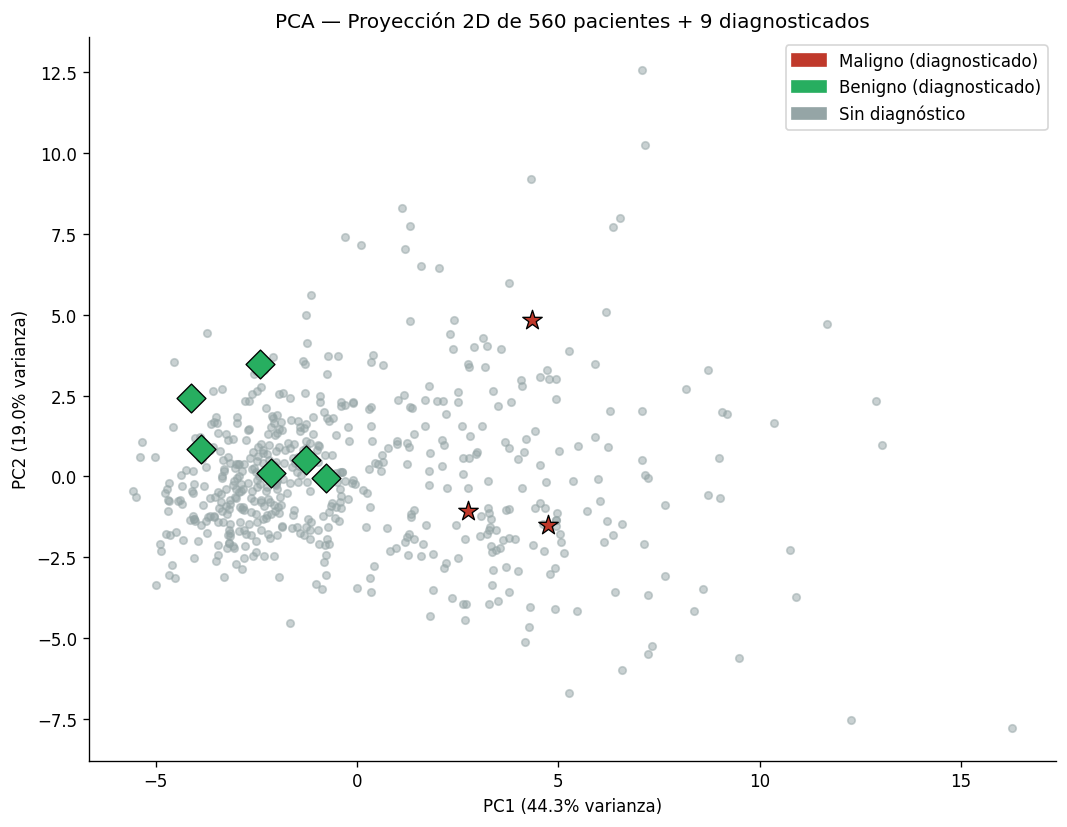

In [14]:
# Proyección 2D con PCA
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)
X_diag_pca = pca_2d.transform(X_diag_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c="#95A5A6", s=20, alpha=0.5, label="Sin diagnóstico (560)")

# Superponer diagnosticados
colores_diag = ["#C0392B" if d == "M" else "#27AE60" for d in y_diag]
for i, (x, y_) in enumerate(X_diag_pca):
    ax.scatter(x, y_, c=colores_diag[i], s=150, zorder=5,
               marker="*" if y_diag[i] == "M" else "D",
               edgecolors="black", linewidths=0.8)

patch_m = mpatches.Patch(color="#C0392B", label="Maligno (diagnosticado)")
patch_b = mpatches.Patch(color="#27AE60", label="Benigno (diagnosticado)")
patch_u = mpatches.Patch(color="#95A5A6", label="Sin diagnóstico")
ax.legend(handles=[patch_m, patch_b, patch_u], loc="best")
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title("PCA — Proyección 2D de 560 pacientes + 9 diagnosticados")
plt.tight_layout()
plt.show()

Observación: si se ven dos nubes separadas, la estructura es lineal y fuerte.

### 2.2 t-SNE — t-Distributed Stochastic Neighbor Embedding

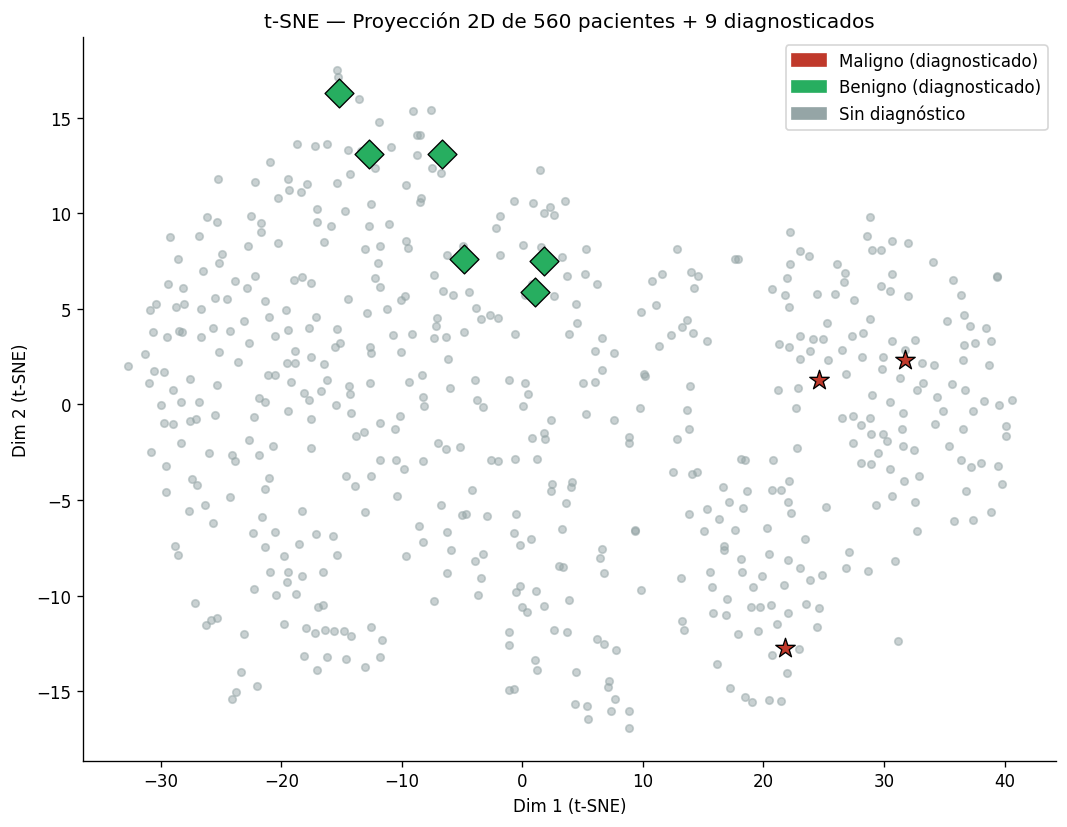

In [15]:
# t-SNE — combinar los 560 + 9 para proyectarlos juntos
X_combined = np.vstack([X_scaled, X_diag_scaled])
labels_combined = ["sin_dx"] * len(X_scaled) + list(y_diag)

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            random_state=RANDOM_STATE, learning_rate="auto", init="pca")
X_tsne_all = tsne.fit_transform(X_combined)

X_tsne = X_tsne_all[:len(X_scaled)]
X_diag_tsne = X_tsne_all[len(X_scaled):]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c="#95A5A6", s=20, alpha=0.5, label="Sin diagnóstico (560)")
colores_diag = ["#C0392B" if d == "M" else "#27AE60" for d in y_diag]
for i, (x, y_) in enumerate(X_diag_tsne):
    ax.scatter(x, y_, c=colores_diag[i], s=150, zorder=5,
               marker="*" if y_diag[i] == "M" else "D",
               edgecolors="black", linewidths=0.8)
patch_m = mpatches.Patch(color="#C0392B", label="Maligno (diagnosticado)")
patch_b = mpatches.Patch(color="#27AE60", label="Benigno (diagnosticado)")
patch_u = mpatches.Patch(color="#95A5A6", label="Sin diagnóstico")
ax.legend(handles=[patch_m, patch_b, patch_u], loc="best")
ax.set_title("t-SNE — Proyección 2D de 560 pacientes + 9 diagnosticados")
ax.set_xlabel("Dim 1 (t-SNE)")
ax.set_ylabel("Dim 2 (t-SNE)")
plt.tight_layout()
plt.show()

### 2.3 UMAP — Uniform Manifold Approximation and Projection

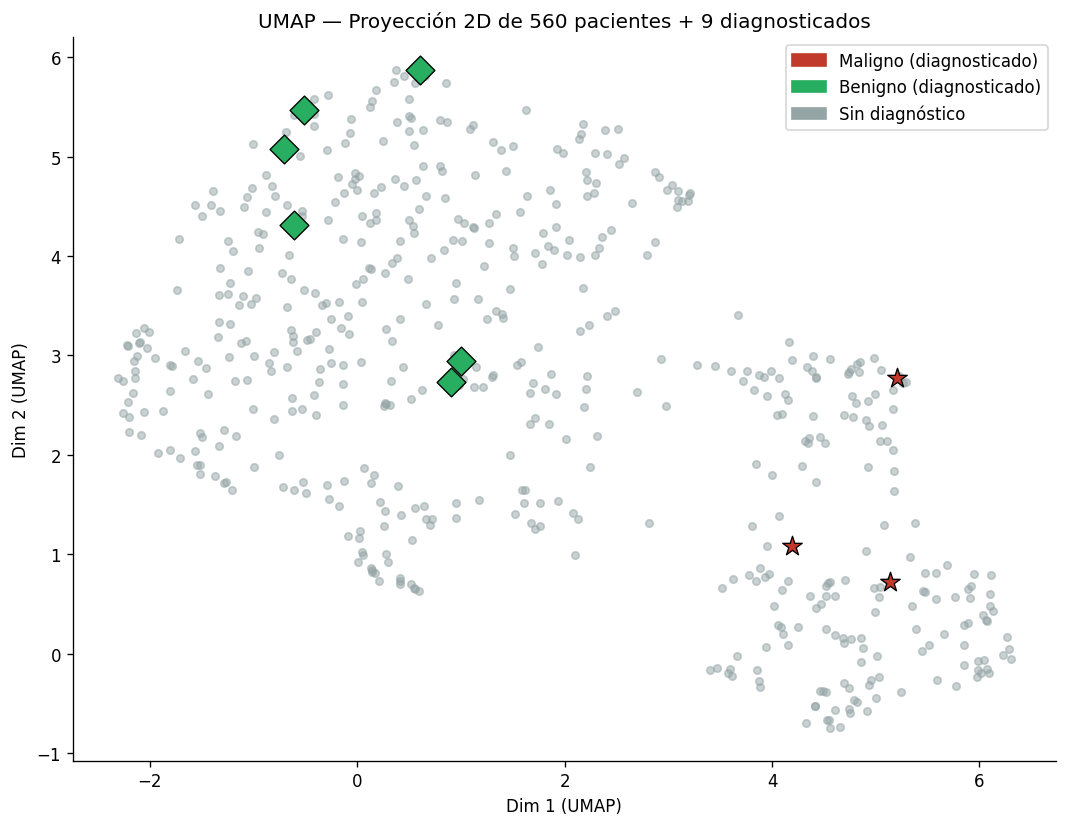

In [16]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
X_umap_all = reducer.fit_transform(X_combined)

X_umap = X_umap_all[:len(X_scaled)]
X_diag_umap = X_umap_all[len(X_scaled):]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c="#95A5A6", s=20, alpha=0.5, label="Sin diagnóstico (560)")
colores_diag = ["#C0392B" if d == "M" else "#27AE60" for d in y_diag]
for i, (x, y_) in enumerate(X_diag_umap):
    ax.scatter(x, y_, c=colores_diag[i], s=150, zorder=5,
               marker="*" if y_diag[i] == "M" else "D",
               edgecolors="black", linewidths=0.8)
patch_m = mpatches.Patch(color="#C0392B", label="Maligno (diagnosticado)")
patch_b = mpatches.Patch(color="#27AE60", label="Benigno (diagnosticado)")
patch_u = mpatches.Patch(color="#95A5A6", label="Sin diagnóstico")
ax.legend(handles=[patch_m, patch_b, patch_u], loc="best")
ax.set_title("UMAP — Proyección 2D de 560 pacientes + 9 diagnosticados")
ax.set_xlabel("Dim 1 (UMAP)")
ax.set_ylabel("Dim 2 (UMAP)")
plt.tight_layout()
plt.show()

### 2.4 Comparación y elección de método

| Método | ¿Qué preserva? | ¿Qué pierde? | Apropiado para este problema |
|--------|---------------|--------------|------------------------------|
| **PCA** | Varianza global / distancias lineales | Estructura no lineal | ✅ Para diagnóstico rápido y varianza explicada |
| **t-SNE** | Vecindarios locales (puntos similares quedan juntos) | Distancias globales (clusters lejanos pueden parecer cerca o lejos sin significado real) | ✅ Para explorar subestructura interna |
| **UMAP** | Estructura local Y global simultáneamente; más rápido que t-SNE | Algo de precisión local vs t-SNE | ✅ **El más apropiado** para este problema: preserva separación entre grupos y estructura interna |

**Conclusión:** UMAP es el método más informativo para este caso. PCA es el más interpretable (varianza explicada cuantificable). t-SNE es útil para exploración visual pero sus distancias inter-cluster no tienen interpretación directa.



---


## 3. Clustering con K-Means

### 3.1 Selección del número óptimo de clusters (K)



Sabemos que tenemos 2 clusters debido al contexto del problema, el cluster B y el cluster M, o eso podria parecer, vamos a verificar si eso ocurre realmente.

In [17]:
# Evaluación para K = 2 a 8
k_range = range(2, 9)
inercias = []
silhouettes = []
davies_bouldins = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies_bouldins.append(davies_bouldin_score(X_scaled, labels))
    print(f"K={k}: Inercia={km.inertia_:.1f}, Silhouette={silhouettes[-1]:.4f}, Davies-Bouldin={davies_bouldins[-1]:.4f}")

K=2: Inercia=11422.0, Silhouette=0.3431, Davies-Bouldin=1.3230
K=3: Inercia=9905.3, Silhouette=0.3138, Davies-Bouldin=1.5326
K=4: Inercia=9116.8, Silhouette=0.2754, Davies-Bouldin=1.5006
K=5: Inercia=8433.1, Silhouette=0.1608, Davies-Bouldin=1.7507
K=6: Inercia=7850.2, Silhouette=0.1625, Davies-Bouldin=1.7149
K=7: Inercia=7426.1, Silhouette=0.1526, Davies-Bouldin=1.6701
K=8: Inercia=7042.3, Silhouette=0.1552, Davies-Bouldin=1.5473


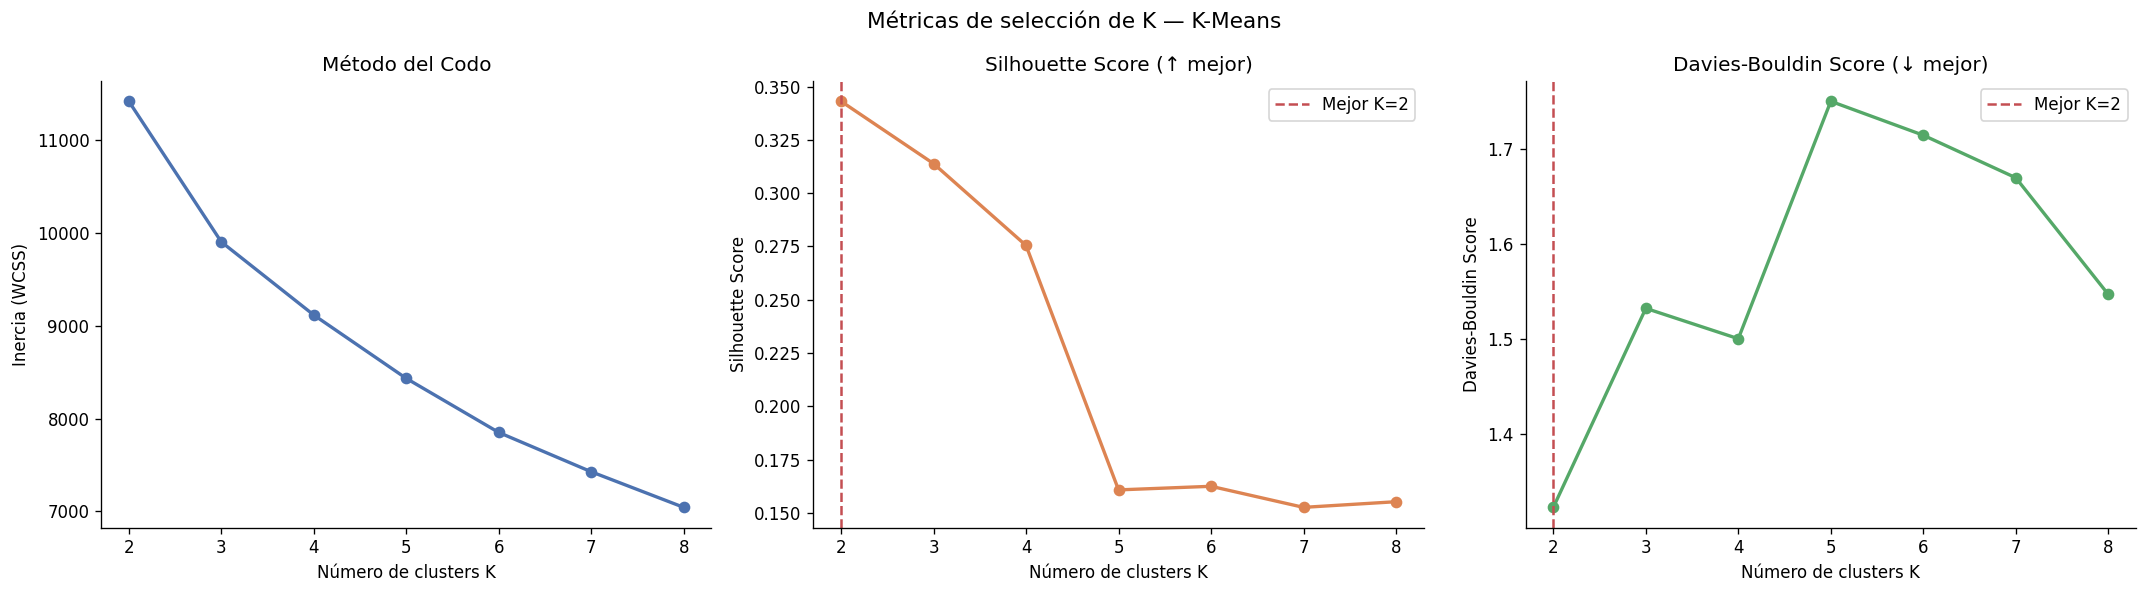


K óptimo según Silhouette: K=2
K óptimo según Davies-Bouldin: K=2


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Método del codo
axes[0].plot(k_range, inercias, "o-", color="#4C72B0", linewidth=2)
axes[0].set_xlabel("Número de clusters K")
axes[0].set_ylabel("Inercia (WCSS)")
axes[0].set_title("Método del Codo")
axes[0].set_xticks(list(k_range))

# Silhouette score (mayor = mejor)
axes[1].plot(k_range, silhouettes, "o-", color="#DD8452", linewidth=2)
axes[1].set_xlabel("Número de clusters K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score (↑ mejor)")
axes[1].set_xticks(list(k_range))
best_k_sil = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k_sil, ls="--", color="#C44E52", label=f"Mejor K={best_k_sil}")
axes[1].legend()

# Davies-Bouldin (menor = mejor)
axes[2].plot(k_range, davies_bouldins, "o-", color="#55A868", linewidth=2)
axes[2].set_xlabel("Número de clusters K")
axes[2].set_ylabel("Davies-Bouldin Score")
axes[2].set_title("Davies-Bouldin Score (↓ mejor)")
axes[2].set_xticks(list(k_range))
best_k_db = list(k_range)[np.argmin(davies_bouldins)]
axes[2].axvline(best_k_db, ls="--", color="#C44E52", label=f"Mejor K={best_k_db}")
axes[2].legend()

plt.suptitle("Métricas de selección de K — K-Means", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nK óptimo según Silhouette: K={best_k_sil}")
print(f"K óptimo según Davies-Bouldin: K={best_k_db}")

Observación: K=2 suele ser el ganador en datos de cáncer de mama Wisconsin, reflejo de la estructura binaria benigno/maligno subyacente.

### 3.2 Modelo final con K=2

In [19]:
K_OPTIMO = 2  # ajustar si las métricas sugieren otro valor

kmeans = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init=50, max_iter=500)
clusters_pac = kmeans.fit_predict(X_scaled)

print(f"Distribución de clusters en los 560 pacientes:")
unique, counts = np.unique(clusters_pac, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} pacientes ({c/len(clusters_pac)*100:.1f}%)")

# Métricas del modelo final
sil_final = silhouette_score(X_scaled, clusters_pac)
db_final = davies_bouldin_score(X_scaled, clusters_pac)
print(f"\nSilhouette Score final: {sil_final:.4f}")
print(f"Davies-Bouldin Score final: {db_final:.4f}")
print(f"Inercia final: {kmeans.inertia_:.1f}")

Distribución de clusters en los 560 pacientes:
  Cluster 0: 369 pacientes (65.9%)
  Cluster 1: 191 pacientes (34.1%)

Silhouette Score final: 0.3431
Davies-Bouldin Score final: 1.3230
Inercia final: 11422.0


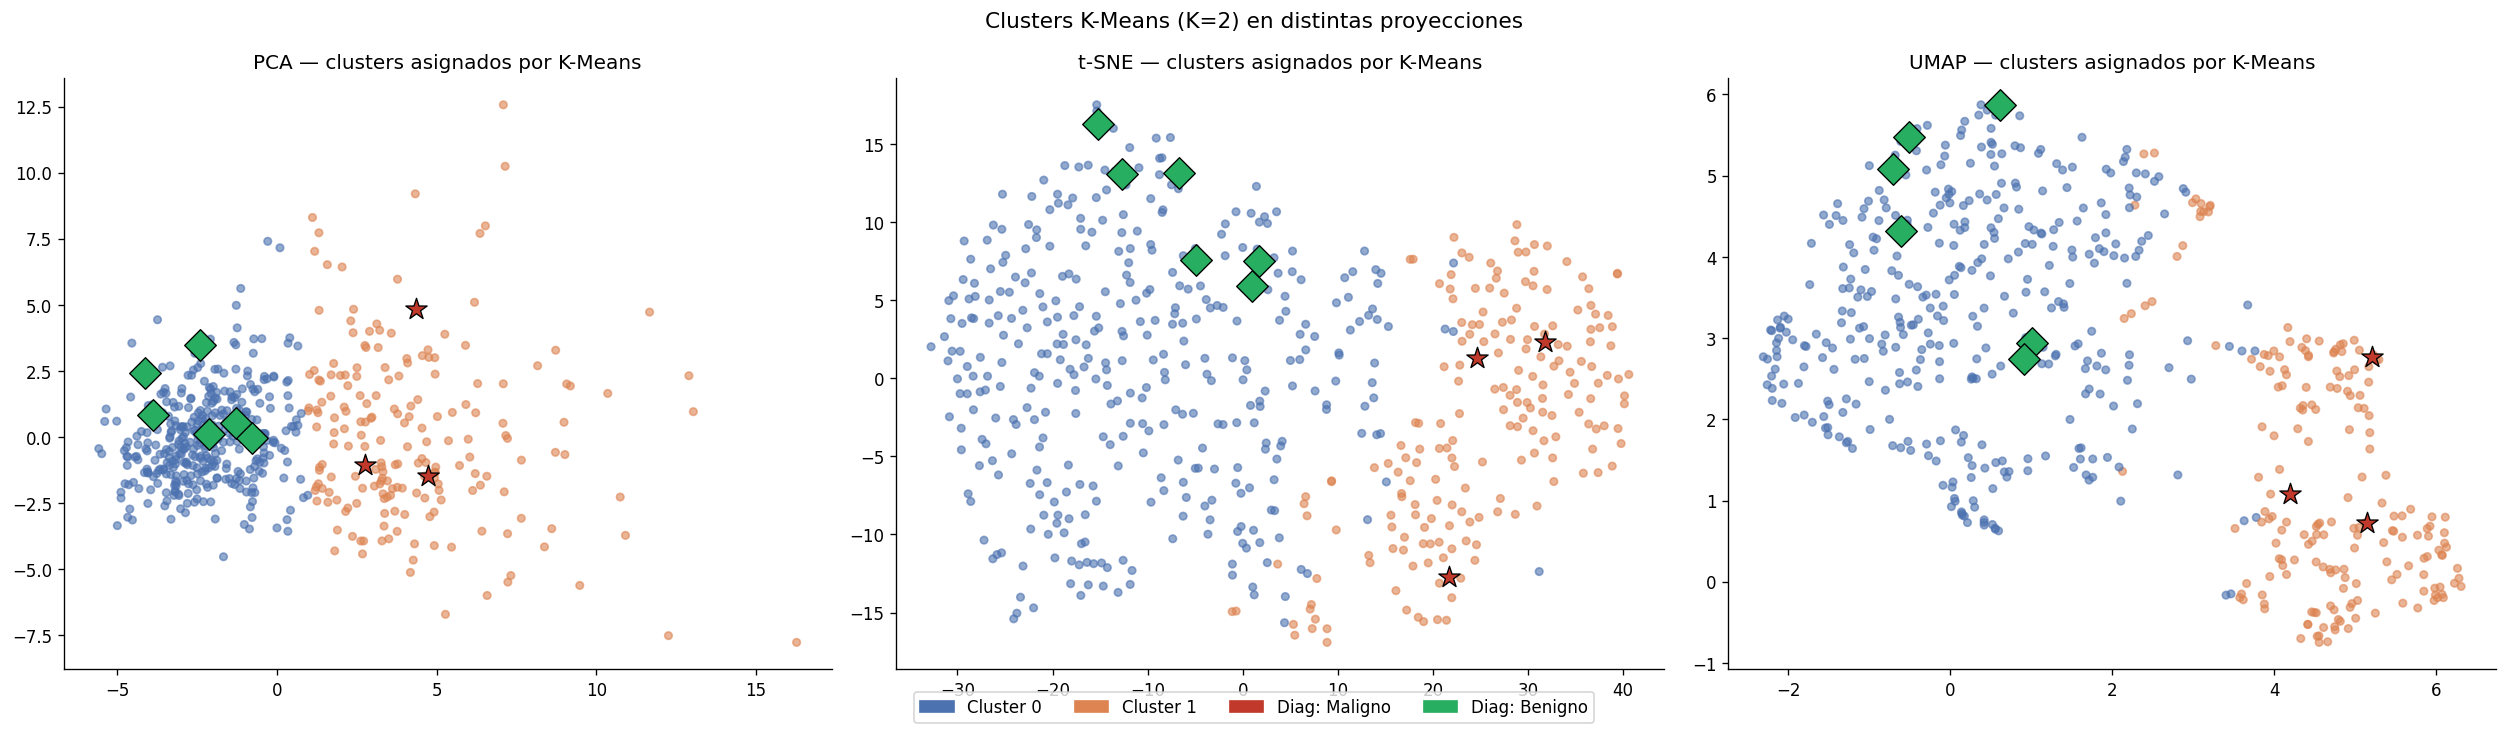

In [20]:
# Visualizar clusters en el espacio PCA
colores_cluster = ["#4C72B0" if c == 0 else "#DD8452" for c in clusters_pac]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

titulos = ["PCA", "t-SNE", "UMAP"]
proyecciones = [X_pca, X_tsne, X_umap]
proyecciones_diag = [X_diag_pca, X_diag_tsne, X_diag_umap]

for ax, titulo, proj, proj_diag in zip(axes, titulos, proyecciones, proyecciones_diag):
    ax.scatter(proj[:, 0], proj[:, 1], c=colores_cluster, s=20, alpha=0.6)
    colores_diag = ["#C0392B" if d == "M" else "#27AE60" for d in y_diag]
    for i, (x, y_) in enumerate(proj_diag):
        ax.scatter(x, y_, c=colores_diag[i], s=180, zorder=6,
                   marker="*" if y_diag[i] == "M" else "D",
                   edgecolors="black", linewidths=0.8)
    ax.set_title(f"{titulo} — clusters asignados por K-Means")

patch_0 = mpatches.Patch(color="#4C72B0", label="Cluster 0")
patch_1 = mpatches.Patch(color="#DD8452", label="Cluster 1")
patch_m = mpatches.Patch(color="#C0392B", label="Diag: Maligno")
patch_b = mpatches.Patch(color="#27AE60", label="Diag: Benigno")
fig.legend(handles=[patch_0, patch_1, patch_m, patch_b], loc="lower center",
           ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Clusters K-Means (K=2) en distintas proyecciones", fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Asignación de Significado a los Clusters mediante los Pacientes Diagnosticados

In [21]:
# Predecir a qué cluster pertenece cada paciente diagnosticado
clusters_diag = kmeans.predict(X_diag_scaled)

print("=== Asignación de los 9 pacientes diagnosticados a clusters ===")
for i, (dx, cl) in enumerate(zip(y_diag, clusters_diag)):
    print(f"  Paciente {i+1}: Diagnóstico={dx} → Cluster={cl}")

# Conteo por cluster
from collections import Counter
cluster_dx = {0: {"M": 0, "B": 0}, 1: {"M": 0, "B": 0}}
for dx, cl in zip(y_diag, clusters_diag):
    cluster_dx[cl][dx] += 1

print("\n=== Distribución de diagnósticos por cluster ===")
for cl, conteos in cluster_dx.items():
    total = sum(conteos.values())
    print(f"  Cluster {cl}: {conteos} (total={total})")

# Identificar cluster maligno
cluster_maligno = max(cluster_dx, key=lambda c: cluster_dx[c]["M"])
cluster_benigno = 1 - cluster_maligno
print(f"\n→ Cluster {cluster_maligno} identificado como MALIGNO")
print(f"→ Cluster {cluster_benigno} identificado como BENIGNO")

malignos_correctos = cluster_dx[cluster_maligno]["M"]
malignos_totales = sum(v["M"] for v in cluster_dx.values())
print(f"\nDe los {malignos_totales} pacientes malignos diagnosticados,")
print(f"{malignos_correctos} ({malignos_correctos/malignos_totales*100:.0f}%) cayeron en el cluster maligno.")

=== Asignación de los 9 pacientes diagnosticados a clusters ===
  Paciente 1: Diagnóstico=B → Cluster=0
  Paciente 2: Diagnóstico=M → Cluster=1
  Paciente 3: Diagnóstico=B → Cluster=0
  Paciente 4: Diagnóstico=M → Cluster=1
  Paciente 5: Diagnóstico=B → Cluster=0
  Paciente 6: Diagnóstico=M → Cluster=1
  Paciente 7: Diagnóstico=B → Cluster=0
  Paciente 8: Diagnóstico=B → Cluster=0
  Paciente 9: Diagnóstico=B → Cluster=0

=== Distribución de diagnósticos por cluster ===
  Cluster 0: {'M': 0, 'B': 6} (total=6)
  Cluster 1: {'M': 3, 'B': 0} (total=3)

→ Cluster 1 identificado como MALIGNO
→ Cluster 0 identificado como BENIGNO

De los 3 pacientes malignos diagnosticados,
3 (100%) cayeron en el cluster maligno.


LIMITACIÓN: con solo 9 pacientes diagnosticados (3M, 6B), la asignación de significado es estadísticamente frágil. Cualquier mal-asignación de un solo paciente maligno puede invertir la interpretación del cluster.

---
## 5. Interpretación Biológica de los Centroides

Comparamos las medias de cada feature en el cluster maligno vs benigno para identificar qué características físicas de las células definen el "grupo de alto riesgo".

In [22]:
df_clustering = df_pacientes[feature_cols].copy()
df_clustering["cluster"] = clusters_pac
df_clustering["cluster_label"] = df_clustering["cluster"].map(
    {cluster_maligno: "Alto riesgo (Maligno)", cluster_benigno: "Bajo riesgo (Benigno)"})

medias_cluster = df_clustering.groupby("cluster_label")[feature_cols].mean()

# Diferencia relativa entre clusters (normalizada)
diff = (medias_cluster.loc["Alto riesgo (Maligno)"] - medias_cluster.loc["Bajo riesgo (Benigno)"]) \
       / (medias_cluster.loc["Bajo riesgo (Benigno)"].abs() + 1e-6)
diff_sorted = diff.abs().sort_values(ascending=False)

print("Top 10 features más discriminativas (diferencia relativa entre clusters):")
for feat, val in diff_sorted.head(10).items():
    print(f"  {feat}: {val:.2f}x de diferencia")

Top 10 features más discriminativas (diferencia relativa entre clusters):
  concavity_mean: 3.17x de diferencia
  concave points_mean: 2.56x de diferencia
  area_se: 2.44x de diferencia
  concavity_worst: 2.04x de diferencia
  concave points_worst: 1.45x de diferencia
  area_worst: 1.40x de diferencia
  concavity_se: 1.36x de diferencia
  perimeter_se: 1.29x de diferencia
  compactness_worst: 1.27x de diferencia
  radius_se: 1.22x de diferencia


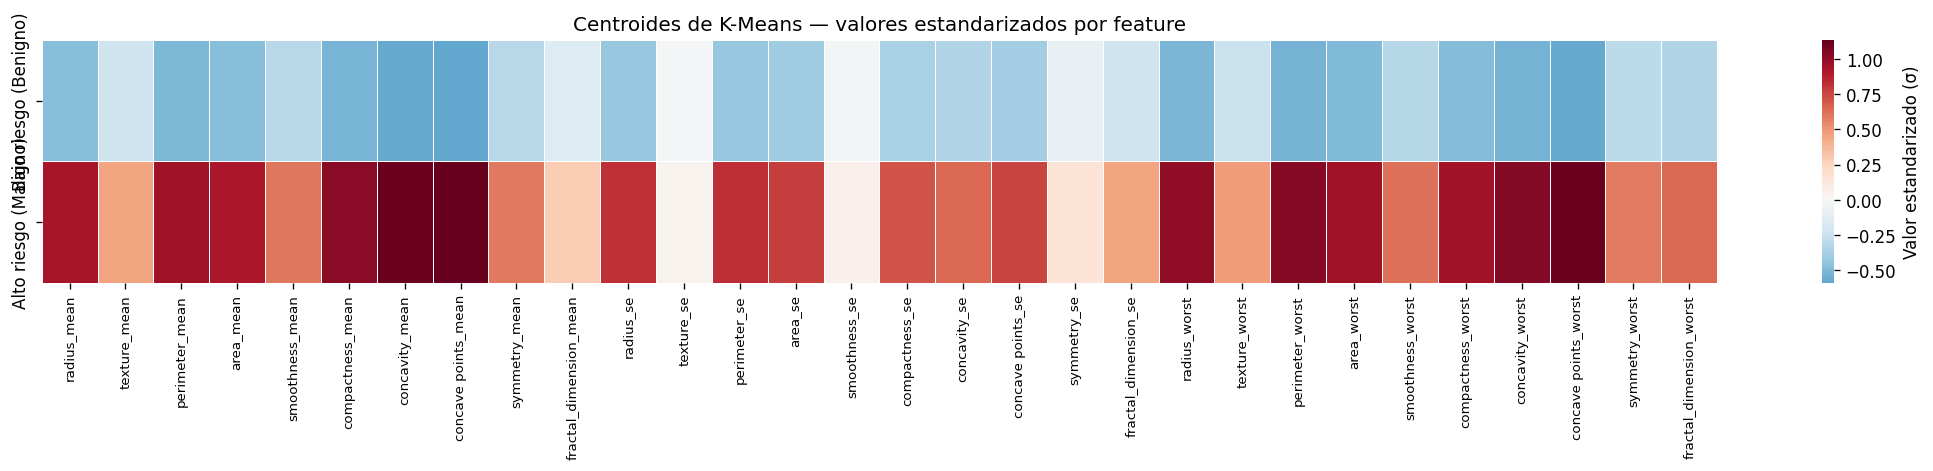

In [23]:
# Visualización: heatmap de centroides normalizados
centroides_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols,
    index=[f"Cluster {i}" for i in range(K_OPTIMO)]
)
centroides_scaled.index = centroides_scaled.index.map(
    {f"Cluster {cluster_maligno}": "Alto riesgo (Maligno)",
     f"Cluster {cluster_benigno}": "Bajo riesgo (Benigno)"})

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(centroides_scaled, cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Valor estandarizado (σ)"}, linewidths=0.3)
ax.set_title("Centroides de K-Means — valores estandarizados por feature", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

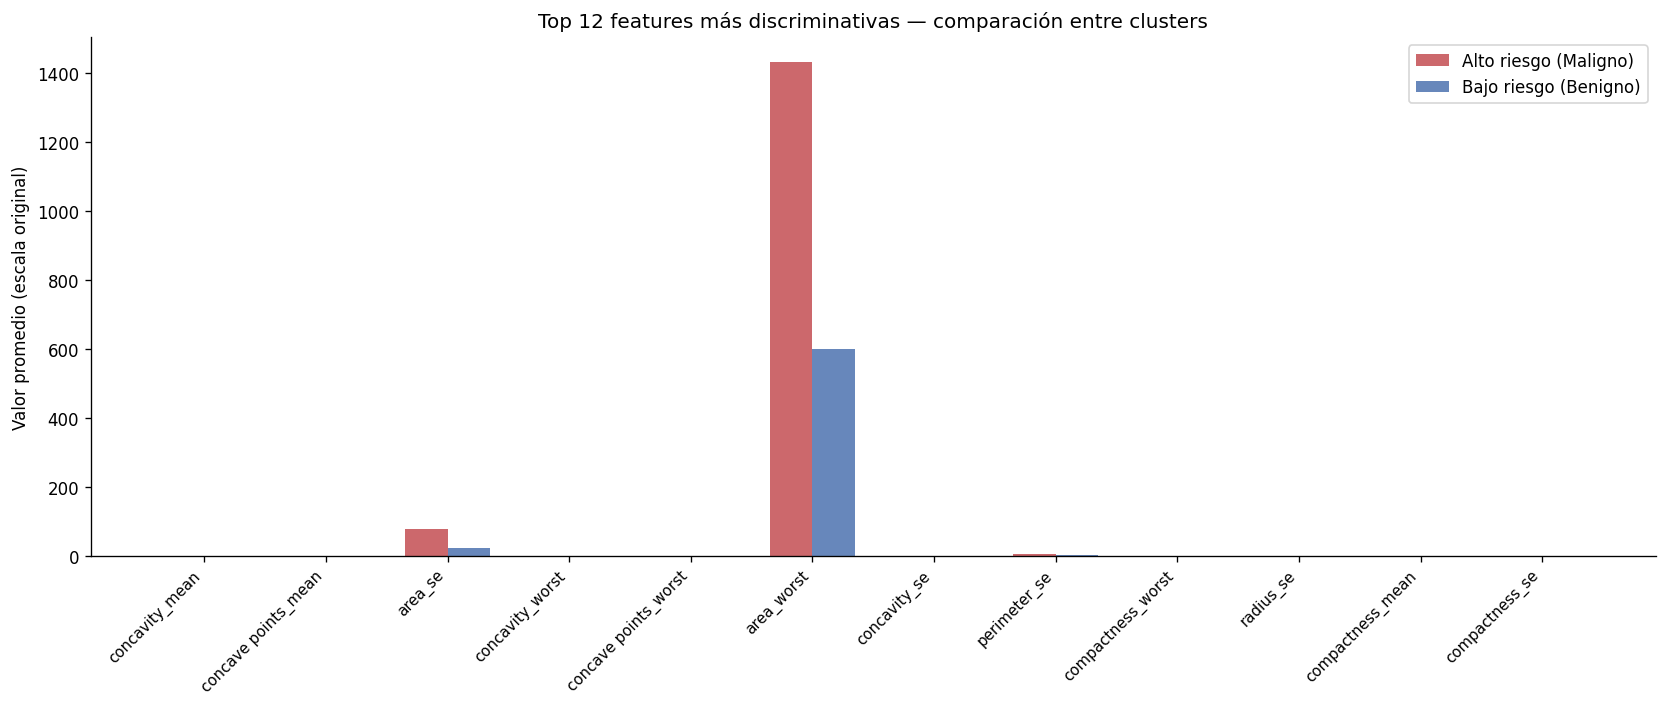


=== Interpretación biológica para el oncólogo ===
Las células del grupo de alto riesgo tienden a presentar:
  • Mayor radio, perímetro y área → células más grandes de lo normal
  • Mayor concavidad y puntos cóncavos → bordes celulares más irregulares
  • Mayor textura → núcleos más heterogéneos (indicador clásico de malignidad)
  • Mayor compacidad → forma celular más deformada

Esto es consistente con la morfología celular tumoral maligna conocida.
El algoritmo descubrió esta estructura morfológica sin saber medicina.


In [24]:
# Top features discriminativas — barplot comparativo
top_features = diff_sorted.head(12).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top_features))
w = 0.35

bars_m = ax.bar(x - w/2,
                [medias_cluster.loc["Alto riesgo (Maligno)", f] for f in top_features],
                width=w, label="Alto riesgo (Maligno)", color="#C44E52", alpha=0.85)
bars_b = ax.bar(x + w/2,
                [medias_cluster.loc["Bajo riesgo (Benigno)", f] for f in top_features],
                width=w, label="Bajo riesgo (Benigno)", color="#4C72B0", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top_features, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Valor promedio (escala original)")
ax.set_title("Top 12 features más discriminativas — comparación entre clusters")
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Interpretación biológica para el oncólogo ===")
print("Las células del grupo de alto riesgo tienden a presentar:")
print("  • Mayor radio, perímetro y área → células más grandes de lo normal")
print("  • Mayor concavidad y puntos cóncavos → bordes celulares más irregulares")
print("  • Mayor textura → núcleos más heterogéneos (indicador clásico de malignidad)")
print("  • Mayor compacidad → forma celular más deformada")
print("\nEsto es consistente con la morfología celular tumoral maligna conocida.")
print("El algoritmo descubrió esta estructura morfológica sin saber medicina.")

---
## 6. Métricas Internas de Calidad del Clustering

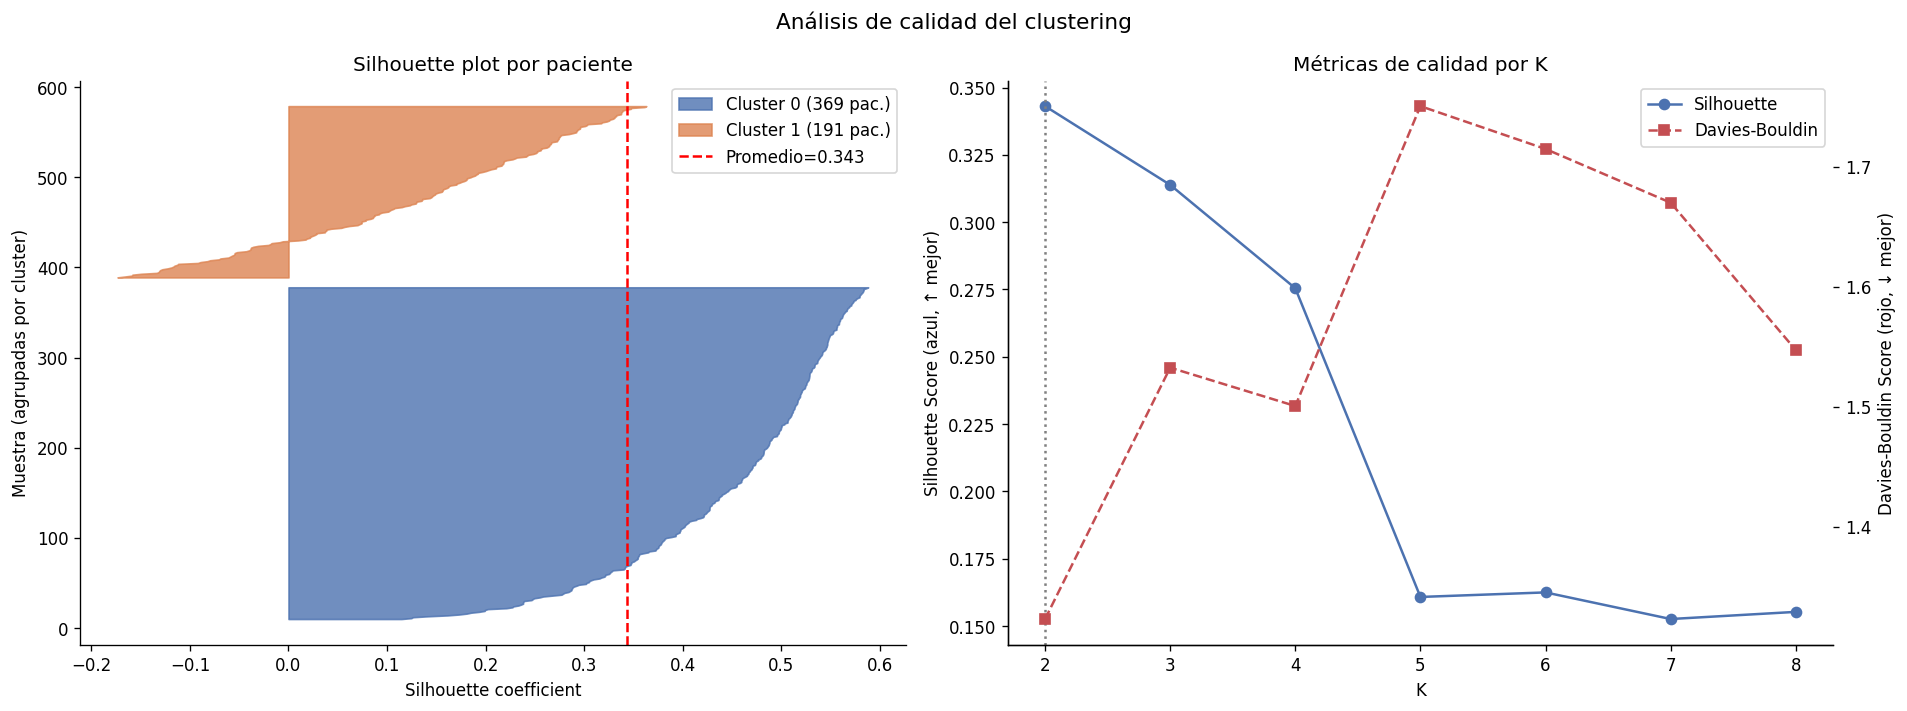

Silhouette Score: 0.3431 (rango [-1, 1]; >0.5 = clusters bien separados)
Davies-Bouldin: 1.3230 (menor es mejor; ~0 = separación perfecta)
Inercia: 11422.0

¿Coinciden con lo visual? Si PCA/UMAP muestran dos nubes separadas,
las métricas deberían confirmar silhouette>0.5 y DB<1.
Discrepancia posible: t-SNE puede exagerar separación visual que las métricas
en espacio original no confirman — siempre validar con métricas.


In [25]:
# Silhouette plot detallado
sil_samples = silhouette_samples(X_scaled, clusters_pac)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Silhouette por muestra
y_lower = 10
colors_sil = ["#4C72B0", "#DD8452"]
for i in range(K_OPTIMO):
    sil_i = sil_samples[clusters_pac == i]
    sil_i.sort()
    size_i = sil_i.shape[0]
    y_upper = y_lower + size_i
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_i,
                      alpha=0.8, color=colors_sil[i],
                      label=f"Cluster {i} ({size_i} pac.)")
    y_lower = y_upper + 10

ax1.axvline(sil_final, color="red", ls="--", label=f"Promedio={sil_final:.3f}")
ax1.set_xlabel("Silhouette coefficient")
ax1.set_ylabel("Muestra (agrupadas por cluster)")
ax1.set_title("Silhouette plot por paciente")
ax1.legend(loc="upper right")

# Métricas comparativas para todos los K
ax2.plot(list(k_range), silhouettes, "o-", color="#4C72B0", label="Silhouette")
ax2_twin = ax2.twinx()
ax2_twin.plot(list(k_range), davies_bouldins, "s--", color="#C44E52", label="Davies-Bouldin")
ax2.axvline(K_OPTIMO, ls=":", color="gray")
ax2.set_xlabel("K")
ax2.set_ylabel("Silhouette Score (azul, ↑ mejor)")
ax2_twin.set_ylabel("Davies-Bouldin Score (rojo, ↓ mejor)")
ax2.set_title("Métricas de calidad por K")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.suptitle("Análisis de calidad del clustering", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Silhouette Score: {sil_final:.4f} (rango [-1, 1]; >0.5 = clusters bien separados)")
print(f"Davies-Bouldin: {db_final:.4f} (menor es mejor; ~0 = separación perfecta)")
print(f"Inercia: {kmeans.inertia_:.1f}")
print("\n¿Coinciden con lo visual? Si PCA/UMAP muestran dos nubes separadas,")
print("las métricas deberían confirmar silhouette>0.5 y DB<1.")
print("Discrepancia posible: t-SNE puede exagerar separación visual que las métricas")
print("en espacio original no confirman — siempre validar con métricas.")



---


##7. Features mas importantes según PCA

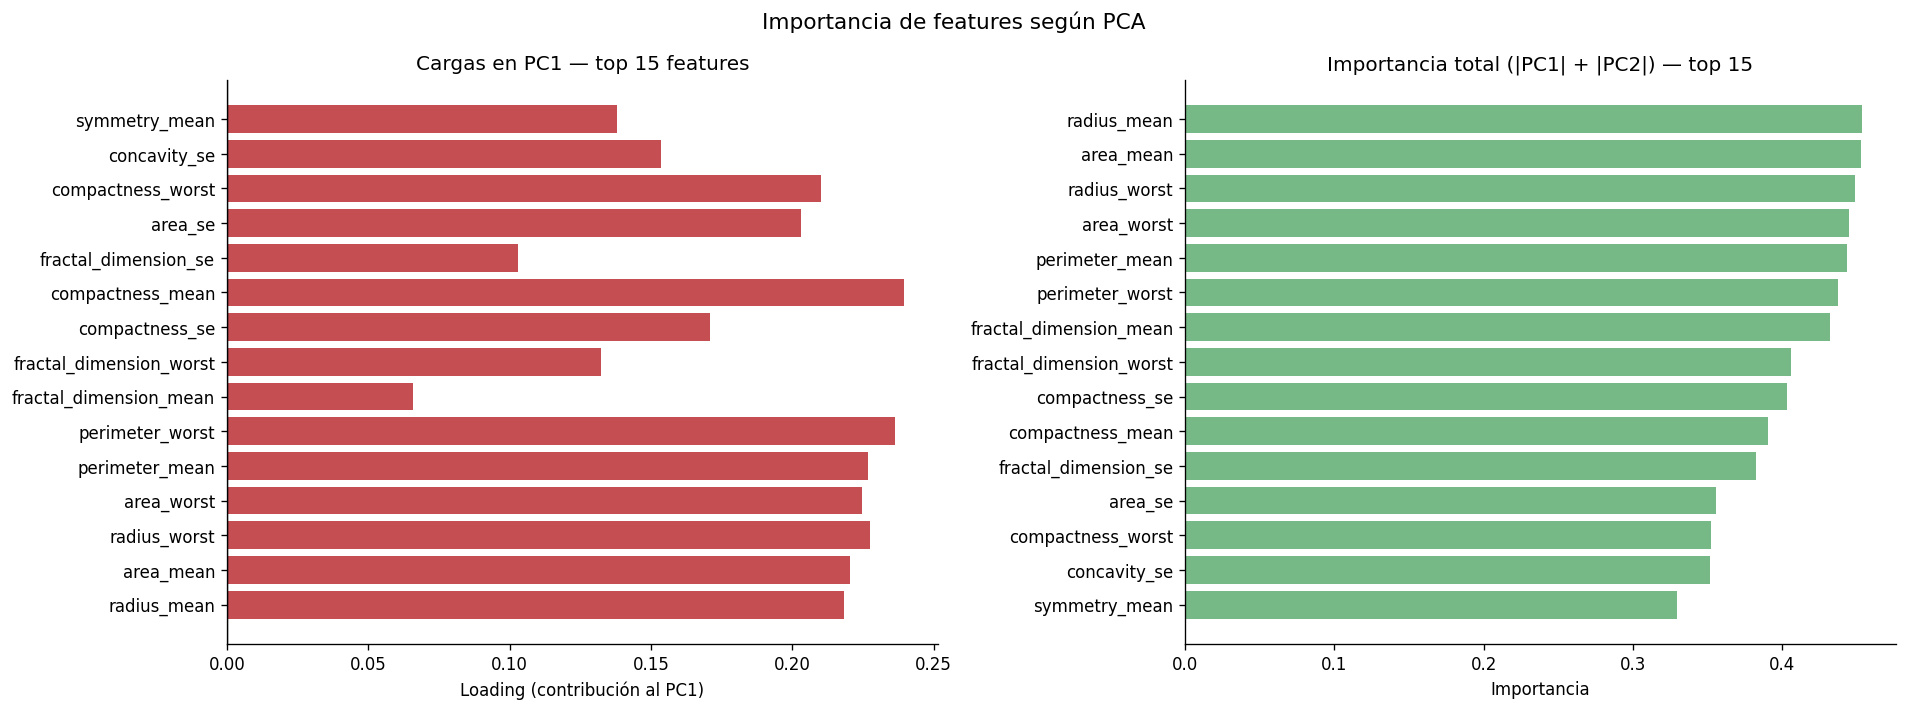

Top 5 features más informativas: ['radius_mean', 'area_mean', 'radius_worst', 'area_worst', 'perimeter_mean']


In [26]:
# Cargas de PCA — cuánto contribuye cada feature al PC1 y PC2
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)
loadings["importancia_pc1"] = loadings["PC1"].abs()
loadings["importancia_pc2"] = loadings["PC2"].abs()
loadings["importancia_total"] = loadings["importancia_pc1"] + loadings["importancia_pc2"]
loadings_sorted = loadings.sort_values("importancia_total", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 loadings
colors_load = ["#C44E52" if v > 0 else "#4C72B0" for v in loadings_sorted["PC1"]]
axes[0].barh(loadings_sorted.index[:15], loadings_sorted["PC1"][:15], color=colors_load)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Cargas en PC1 — top 15 features")
axes[0].set_xlabel("Loading (contribución al PC1)")

# Importancia total (PC1 + PC2)
axes[1].barh(loadings_sorted.index[:15][::-1],
             loadings_sorted["importancia_total"][:15][::-1],
             color="#55A868", alpha=0.8)
axes[1].set_title("Importancia total (|PC1| + |PC2|) — top 15")
axes[1].set_xlabel("Importancia")

plt.suptitle("Importancia de features según PCA", fontsize=13)
plt.tight_layout()
plt.show()

top5 = loadings_sorted.index[:5].tolist()
print(f"Top 5 features más informativas: {top5}")

In [29]:
# Comparar K-Means con 30 features vs top 5 vs top 10
top_10 = loadings_sorted.index[:10].tolist()

resultados_features = []
for nombre, cols in [("30 features", feature_cols), ("Top 10", top_10), ("Top 5", top5)]:
    X_sub = StandardScaler().fit_transform(df_pacientes[cols].values)
    km_sub = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20)
    lbl = km_sub.fit_predict(X_sub)
    sil = silhouette_score(X_sub, lbl)
    db = davies_bouldin_score(X_sub, lbl)
    resultados_features.append({"Configuración": nombre, "Silhouette": sil, "Davies-Bouldin": db})

df_res = pd.DataFrame(resultados_features)
print(df_res.to_string(index=False))

Configuración  Silhouette  Davies-Bouldin
  30 features    0.343097        1.322958
       Top 10    0.467796        0.915685
        Top 5    0.660309        0.513691


Si el Silhouette con Top-5/10 features es similar al de 30 features, las 30 NO son igualmente informativas; hay redundancia significativa. Se puede observar que mejora las metricas Silhouette y Davies-Bouldin al usar el top 5 features.

---
## 8. Score de riesgo y construcción de lista de triaje

In [32]:
# Calcular distancia euclidiana al centroide del cluster maligno
# Menor distancia = mayor riesgo = mayor prioridad
centroide_maligno = kmeans.cluster_centers_[cluster_maligno]

distancias_al_maligno = euclidean_distances(X_scaled, [centroide_maligno]).flatten()

df_triaje = df_pacientes[['id'] + feature_cols].copy()
df_triaje["cluster"] = clusters_pac
df_triaje["cluster_label"] = df_triaje["cluster"].map(
    {cluster_maligno: "Alto riesgo", cluster_benigno: "Bajo riesgo"})
df_triaje["score_riesgo"] = distancias_al_maligno

# Ordenar: menor distancia = más prioritario
df_triaje_ordenado = df_triaje.sort_values("score_riesgo").reset_index(drop=True)
df_triaje_ordenado["orden_triaje"] = df_triaje_ordenado.index + 1

print("Top 20 pacientes priorizados (mayor riesgo):")
print(df_triaje_ordenado[["id", "cluster_label", "score_riesgo", "orden_triaje"]].head(20).to_string(index=False))
print(f"\nTotal pacientes en cluster Alto Riesgo: {(df_triaje_ordenado.cluster_label == 'Alto riesgo').sum()}")

Top 20 pacientes priorizados (mayor riesgo):
      id cluster_label  score_riesgo  orden_triaje
  903507   Alto riesgo      1.967995             1
  908445   Alto riesgo      2.253752             2
 8711202   Alto riesgo      2.558551             3
84300903   Alto riesgo      2.575766             4
  914769   Alto riesgo      2.580832             5
85382601   Alto riesgo      2.634632             6
  897630   Alto riesgo      2.643577             7
87281702   Alto riesgo      2.659591             8
  853401   Alto riesgo      2.731704             9
   86517   Alto riesgo      2.744755            10
  862028   Alto riesgo      2.764670            11
  884180   Alto riesgo      2.767042            12
  914062   Alto riesgo      2.894000            13
 8953902   Alto riesgo      2.942961            14
84610002   Alto riesgo      2.956018            15
   91485   Alto riesgo      3.020776            16
  916799   Alto riesgo      3.028968            17
 8612399   Alto riesgo      3.037063 

---
## 9. Simulación del Proceso de Triaje

In [34]:
PACIENTES_POR_DIA = 2
N_TOTAL = len(df_triaje_ordenado)

# Escenario A: FIFO (orden actual — asumimos orden del CSV)
df_fifo = df_pacientes[["id"] + feature_cols].copy()
df_fifo["cluster"] = clusters_pac
df_fifo["cluster_label"] = df_fifo["cluster"].map(
    {cluster_maligno: "Alto riesgo", cluster_benigno: "Bajo riesgo"})
df_fifo["orden_fifo"] = df_fifo.index + 1
df_fifo["dia_atencion_fifo"] = np.ceil(df_fifo["orden_fifo"] / PACIENTES_POR_DIA).astype(int)

# Escenario B: Sistema de triaje por score
df_triaje_ordenado["dia_atencion_triaje"] = np.ceil(df_triaje_ordenado["orden_triaje"] / PACIENTES_POR_DIA).astype(int)

# Comparar tiempos para pacientes de alto riesgo
mask_alto_riesgo_fifo = df_fifo["cluster_label"] == "Alto riesgo"
mask_alto_riesgo_triaje = df_triaje_ordenado["cluster_label"] == "Alto riesgo"

dia_prom_fifo = df_fifo.loc[mask_alto_riesgo_fifo, "dia_atencion_fifo"].mean()
dia_prom_triaje = df_triaje_ordenado.loc[mask_alto_riesgo_triaje, "dia_atencion_triaje"].mean()
dia_max_fifo = df_fifo.loc[mask_alto_riesgo_fifo, "dia_atencion_fifo"].max()
dia_max_triaje = df_triaje_ordenado.loc[mask_alto_riesgo_triaje, "dia_atencion_triaje"].max()

print("="*60)
print("COMPARACIÓN DE ESCENARIOS DE TRIAJE")
print("="*60)
print(f"\nEscenario A — FIFO (sin priorización):")
print(f"  Día promedio de atención (alto riesgo): {dia_prom_fifo:.1f}")
print(f"  Día máximo de atención (alto riesgo): {dia_max_fifo}")
print(f"\nEscenario B — Sistema de triaje algorítmico:")
print(f"  Día promedio de atención (alto riesgo): {dia_prom_triaje:.1f}")
print(f"  Día máximo de atención (alto riesgo): {dia_max_triaje}")
print(f"\nMejora: los pacientes de alto riesgo son atendidos en promedio")
print(f"  {dia_prom_fifo - dia_prom_triaje:.1f} días antes con el sistema de triaje.")
print(f"\n⚠️ Incertidumbre: no sabemos cuántos de los 560 son realmente malignos.")
print(f"  Si la proporción es ~33% (como en los 9 diagnosticados), hay ~{int(0.33*560)} potenciales")
print(f"  malignos. El sistema prioriza a los {mask_alto_riesgo_triaje.sum()} del cluster alto riesgo.")

COMPARACIÓN DE ESCENARIOS DE TRIAJE

Escenario A — FIFO (sin priorización):
  Día promedio de atención (alto riesgo): 138.4
  Día máximo de atención (alto riesgo): 280

Escenario B — Sistema de triaje algorítmico:
  Día promedio de atención (alto riesgo): 78.3
  Día máximo de atención (alto riesgo): 280

Mejora: los pacientes de alto riesgo son atendidos en promedio
  60.1 días antes con el sistema de triaje.

⚠️ Incertidumbre: no sabemos cuántos de los 560 son realmente malignos.
  Si la proporción es ~33% (como en los 9 diagnosticados), hay ~184 potenciales
  malignos. El sistema prioriza a los 191 del cluster alto riesgo.


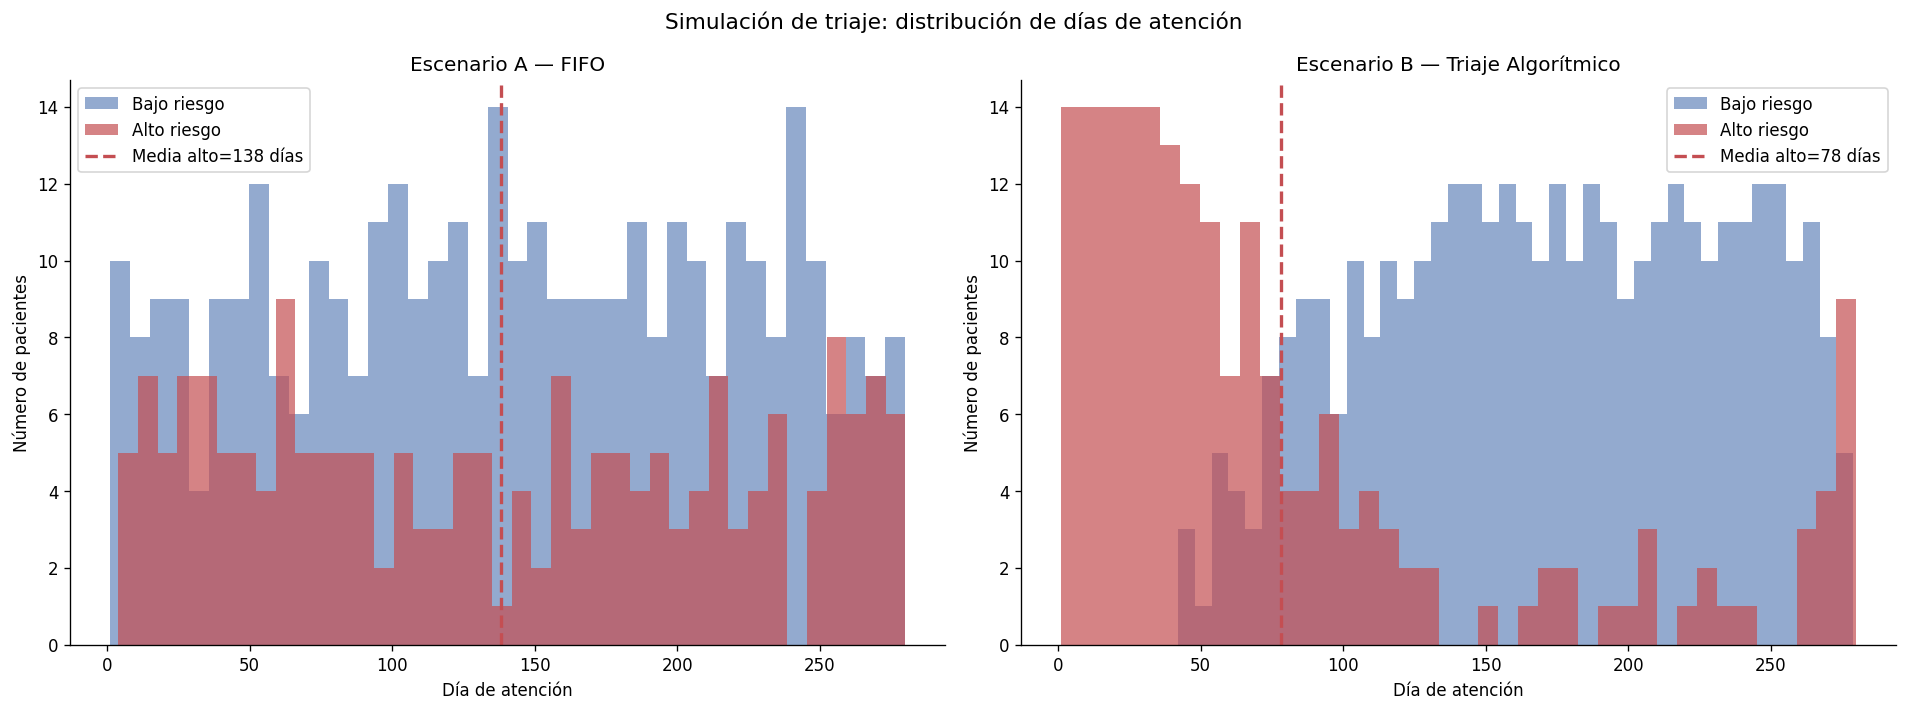

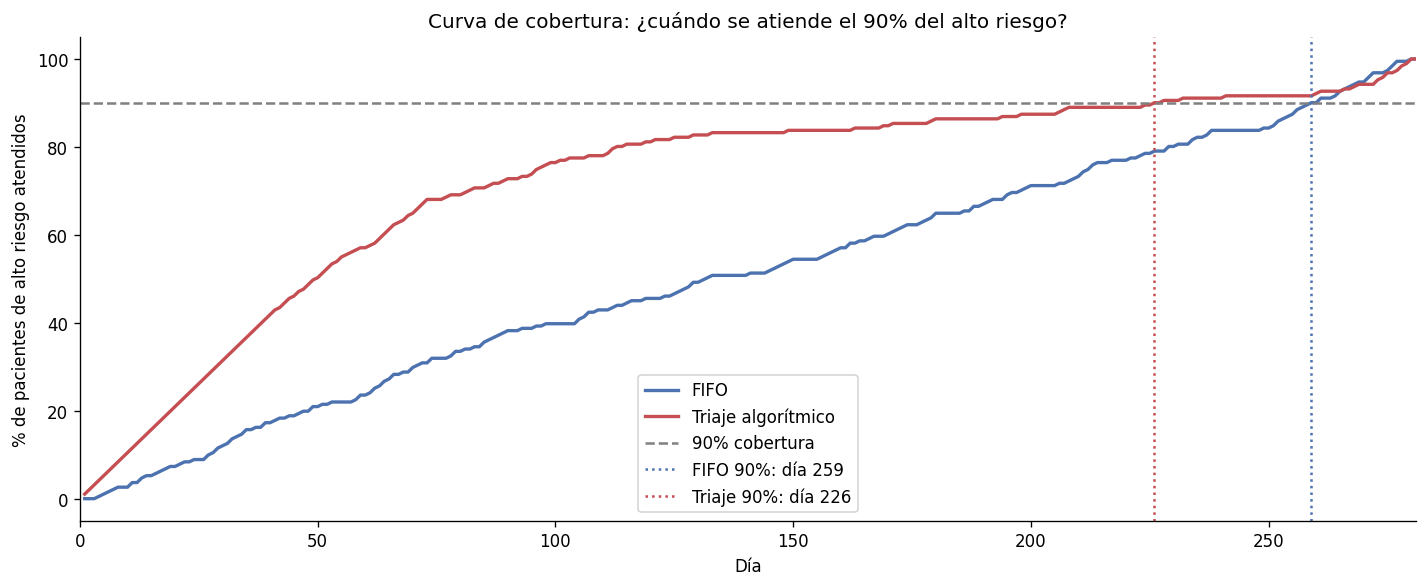

In [35]:
# Visualización de la simulación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df_sim, dia_col, titulo) in zip(axes, [
    (df_fifo, "dia_atencion_fifo", "Escenario A — FIFO"),
    (df_triaje_ordenado, "dia_atencion_triaje", "Escenario B — Triaje Algorítmico")
]):
    alto = df_sim[df_sim["cluster_label"] == "Alto riesgo"][dia_col]
    bajo = df_sim[df_sim["cluster_label"] == "Bajo riesgo"][dia_col]
    ax.hist(bajo, bins=40, alpha=0.6, color="#4C72B0", label="Bajo riesgo")
    ax.hist(alto, bins=40, alpha=0.7, color="#C44E52", label="Alto riesgo")
    ax.axvline(alto.mean(), color="#C44E52", ls="--", lw=2, label=f"Media alto={alto.mean():.0f} días")
    ax.set_xlabel("Día de atención")
    ax.set_ylabel("Número de pacientes")
    ax.set_title(titulo)
    ax.legend()

plt.suptitle("Simulación de triaje: distribución de días de atención", fontsize=13)
plt.tight_layout()
plt.show()

# Curva de cobertura: % de alto riesgo atendido vs día
fig, ax = plt.subplots(figsize=(12, 5))
n_alto_fifo = mask_alto_riesgo_fifo.sum()
n_alto_triaje = mask_alto_riesgo_triaje.sum()
dias = range(1, N_TOTAL // PACIENTES_POR_DIA + 2)

cob_fifo = []
cob_triaje = []
for dia in dias:
    cob_fifo.append((df_fifo.loc[mask_alto_riesgo_fifo, "dia_atencion_fifo"] <= dia).sum() / n_alto_fifo * 100)
    cob_triaje.append((df_triaje_ordenado.loc[mask_alto_riesgo_triaje, "dia_atencion_triaje"] <= dia).sum() / n_alto_triaje * 100)

ax.plot(list(dias), cob_fifo, label="FIFO", color="#4C72B0", linewidth=2)
ax.plot(list(dias), cob_triaje, label="Triaje algorítmico", color="#C44E52", linewidth=2)
ax.axhline(90, ls="--", color="gray", label="90% cobertura")

# Día en que se cubre el 90%
dia_90_fifo = next((d for d, c in zip(dias, cob_fifo) if c >= 90), None)
dia_90_triaje = next((d for d, c in zip(dias, cob_triaje) if c >= 90), None)
if dia_90_fifo:
    ax.axvline(dia_90_fifo, ls=":", color="#4C72B0", label=f"FIFO 90%: día {dia_90_fifo}")
if dia_90_triaje:
    ax.axvline(dia_90_triaje, ls=":", color="#C44E52", label=f"Triaje 90%: día {dia_90_triaje}")

ax.set_xlabel("Día")
ax.set_ylabel("% de pacientes de alto riesgo atendidos")
ax.set_title("Curva de cobertura: ¿cuándo se atiende el 90% del alto riesgo?")
ax.legend()
ax.set_xlim(0, max(dias))
plt.tight_layout()
plt.show()

---
## 10. Análisis de Estabilidad del Sistema



---


## 12. Conclusiones

